# Data Analysis Assignment: EDA & Data Cleaning
### Datasets: Loan Eligibility | Adult Census Income | Hotel Booking Demand

This notebook performs a complete Exploratory Data Analysis (EDA) and Data Cleaning workflow on three datasets, in the required order:
1. **Loan Eligibility Dataset**
2. **Adult Census Income Dataset**
3. **Hotel Booking Dataset**

Every column in every dataset is analyzed (distribution, missing values, outliers) and cleaned. Cleaned datasets are exported at the end of each section.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## Helper Functions
Reusable functions used across all three datasets to analyze and visualize **every column**.

In [2]:

def dataset_overview(df, name):
    print(f"===== {name} : OVERVIEW =====")
    print("Shape:", df.shape)
    print("\nColumn dtypes:\n", df.dtypes)
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nMissing values per column:")
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    display(miss_df[miss_df['missing_count'] > 0].sort_values('missing_count', ascending=False))
    return miss_df

def plot_missing(df, name):
    if df.isnull().sum().sum() == 0:
        print("No missing values to plot.")
        return
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f"{name}: Missing Value Heatmap")
    plt.show()

    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    plt.figure(figsize=(10, 5))
    miss.plot(kind='bar', color='indianred')
    plt.ylabel('Fraction Missing')
    plt.title(f"{name}: Missing Value Fraction by Column")
    plt.tight_layout()
    plt.show()

def analyze_every_column(df, name, max_categories=15):
    """Loop through every column and produce an appropriate univariate plot + summary stats."""
    for col in df.columns:
        print(f"--- {name} | Column: {col} | dtype: {df[col].dtype} ---")
        if pd.api.types.is_numeric_dtype(df[col]):
            display(df[col].describe())
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='steelblue')
            axes[0].set_title(f"{col} - Distribution")
            sns.boxplot(x=df[col].dropna(), ax=axes[1], color='orange')
            axes[1].set_title(f"{col} - Boxplot (outliers)")
            plt.tight_layout()
            plt.show()
        else:
            nunique = df[col].nunique(dropna=True)
            print(f"Unique values: {nunique}")
            vc = df[col].value_counts(dropna=False).head(max_categories)
            display(vc)
            plt.figure(figsize=(10, 4))
            sns.barplot(x=vc.values, y=vc.index.astype(str), palette='viridis')
            plt.title(f"{name} - {col} (top {max_categories} categories)")
            plt.xlabel("Count")
            plt.tight_layout()
            plt.show()

def outlier_summary(df, name):
    """IQR-based outlier count for numeric columns."""
    num_cols = df.select_dtypes(include=np.number).columns
    rows = []
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append([col, lower, upper, n_out])
    out_df = pd.DataFrame(rows, columns=['column', 'lower_bound', 'upper_bound', 'num_outliers'])
    print(f"===== {name}: IQR Outlier Summary =====")
    display(out_df.sort_values('num_outliers', ascending=False))
    return out_df

def correlation_heatmap(df, name):
    num_df = df.select_dtypes(include=np.number)
    if num_df.shape[1] < 2:
        print("Not enough numeric columns for correlation heatmap.")
        return
    plt.figure(figsize=(12, 8))
    sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title(f"{name}: Correlation Heatmap (numeric columns)")
    plt.tight_layout()
    plt.show()


---
# Dataset 1: Loan Eligibility Dataset

Columns: `Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status`

## 1.1 Load Data & Overview


In [3]:
loan_df = pd.read_csv('loan-train.csv')
loan_miss = dataset_overview(loan_df, "Loan Dataset")


===== Loan Dataset : OVERVIEW =====
Shape: (1614, 13)

Column dtypes:
 Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Duplicate rows: 0

Missing values per column:


,missing_count,missing_pct
Credit_History,50,3.10
Self_Employed,32,1.98
LoanAmount,22,1.36
Dependents,15,0.93
Loan_Amount_Term,14,0.87
Gender,13,0.81
Married,3,0.19


## 1.2 Missing Value Visualization

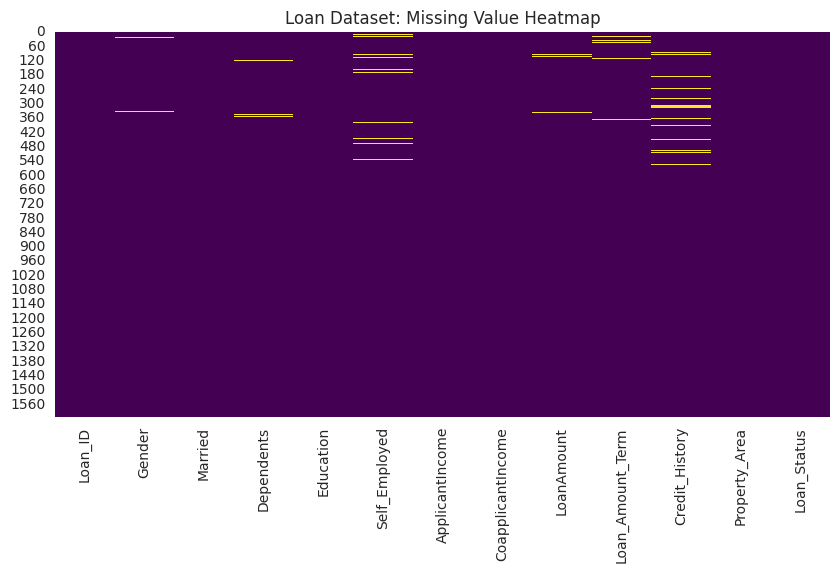

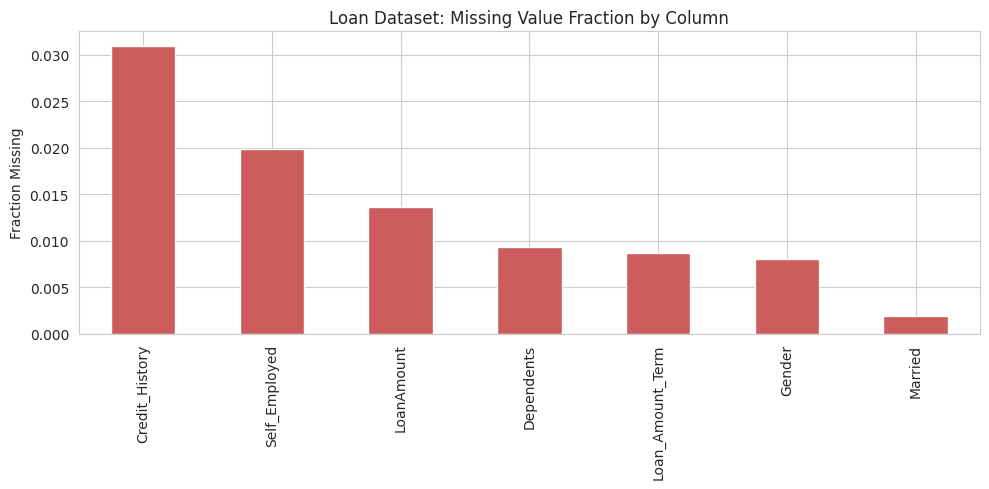

In [4]:
plot_missing(loan_df, "Loan Dataset")

## 1.3 Per-Column Analysis (every column)
`Loan_ID` is a unique identifier so it is excluded from the plotting loop (it has no distributional meaning), but is checked for uniqueness below.

Loan_ID unique values: 1538 out of 1614 rows
--- Loan Dataset | Column: Gender | dtype: str ---
Unique values: 2


Gender
Male      980
Female    621
NaN        13
Name: count, dtype: int64

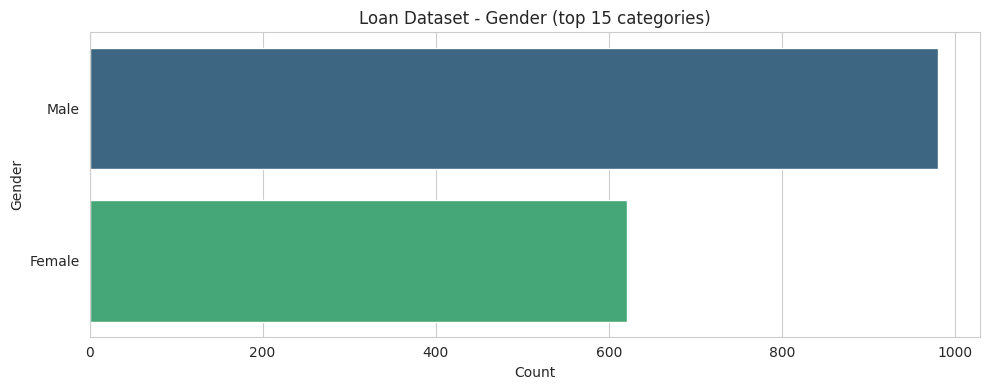

--- Loan Dataset | Column: Married | dtype: str ---
Unique values: 2


Married
Yes    925
No     686
NaN      3
Name: count, dtype: int64

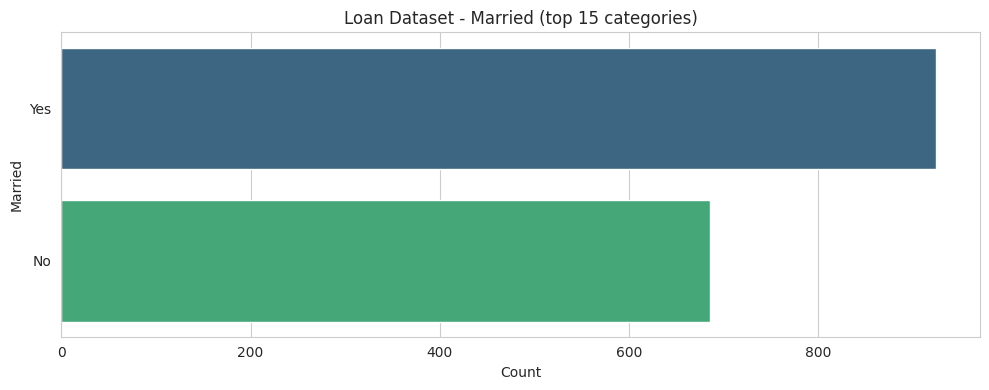

--- Loan Dataset | Column: Dependents | dtype: str ---
Unique values: 4


Dependents
0      619
1      341
2      336
3+     303
NaN     15
Name: count, dtype: int64

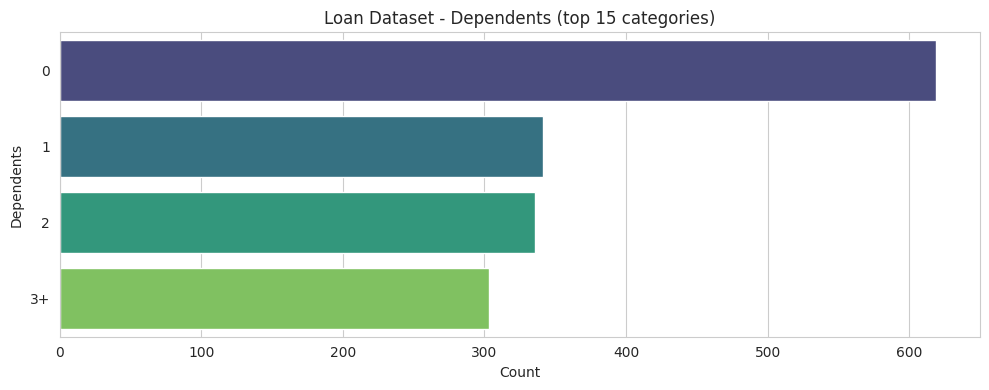

--- Loan Dataset | Column: Education | dtype: str ---
Unique values: 2


Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64

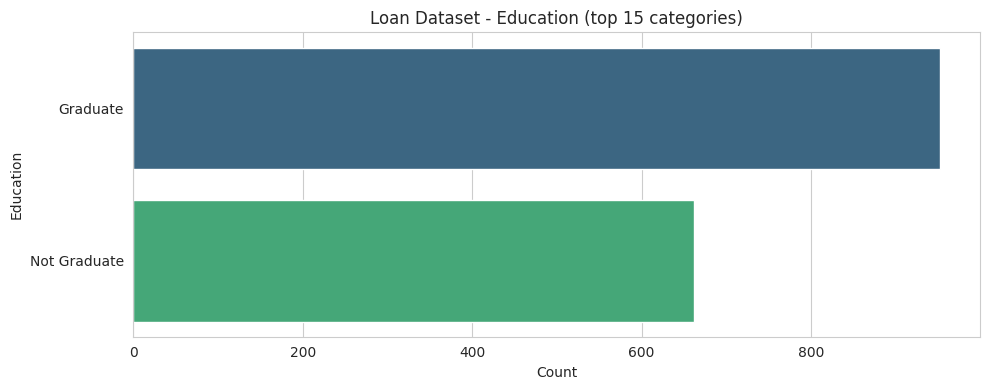

--- Loan Dataset | Column: Self_Employed | dtype: str ---
Unique values: 2


Self_Employed
No     999
Yes    583
NaN     32
Name: count, dtype: int64

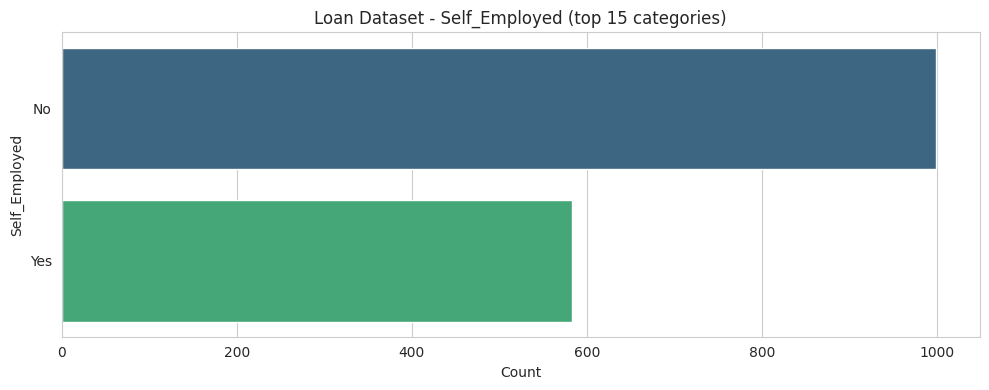

--- Loan Dataset | Column: ApplicantIncome | dtype: int64 ---


count     1614.000000
mean      8746.304833
std       6249.885122
min        150.000000
25%       3675.250000
50%       7045.000000
75%      13251.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

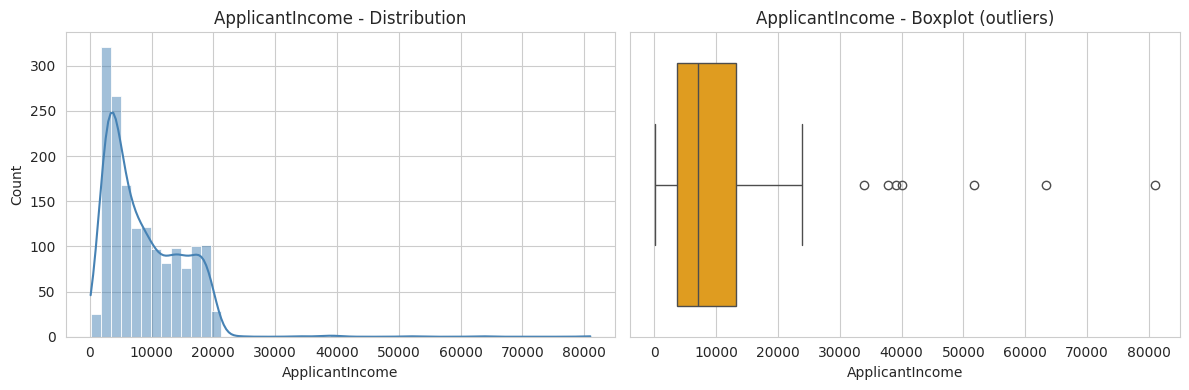

--- Loan Dataset | Column: CoapplicantIncome | dtype: float64 ---


count     1614.000000
mean      3658.722999
std       3291.745935
min          0.000000
25%        986.250000
50%       2941.500000
75%       5893.000000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

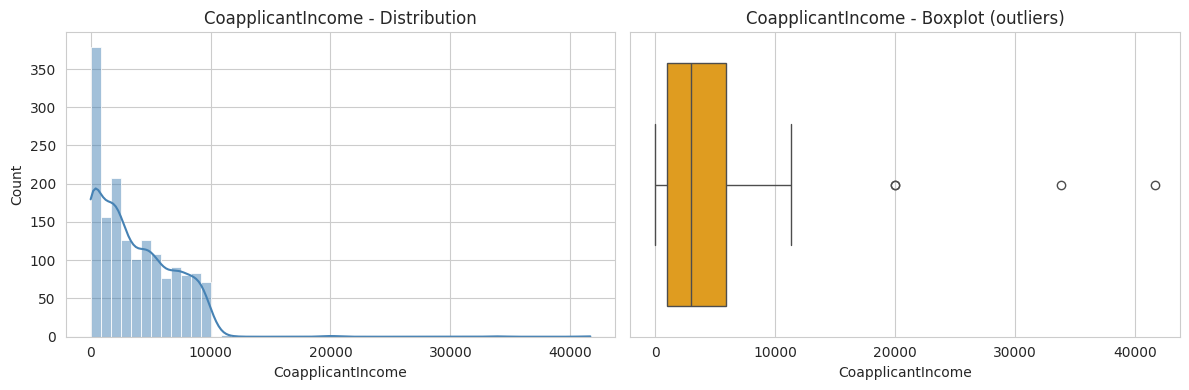

--- Loan Dataset | Column: LoanAmount | dtype: float64 ---


count    1592.000000
mean      218.846734
std       133.623293
min         9.000000
25%       112.000000
50%       180.000000
75%       324.000000
max       700.000000
Name: LoanAmount, dtype: float64

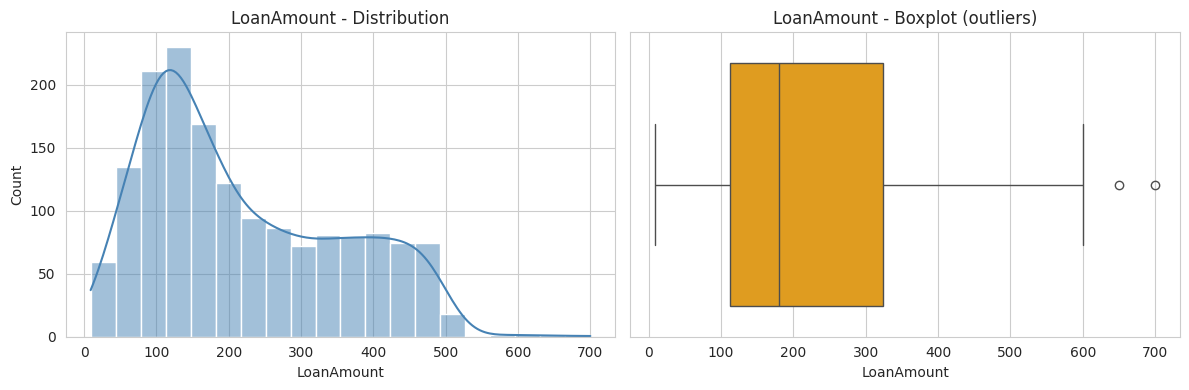

--- Loan Dataset | Column: Loan_Amount_Term | dtype: float64 ---


count    1600.000000
mean      290.475000
std        81.899735
min        12.000000
25%       240.000000
50%       360.000000
75%       360.000000
max       480.000000
Name: Loan_Amount_Term, dtype: float64

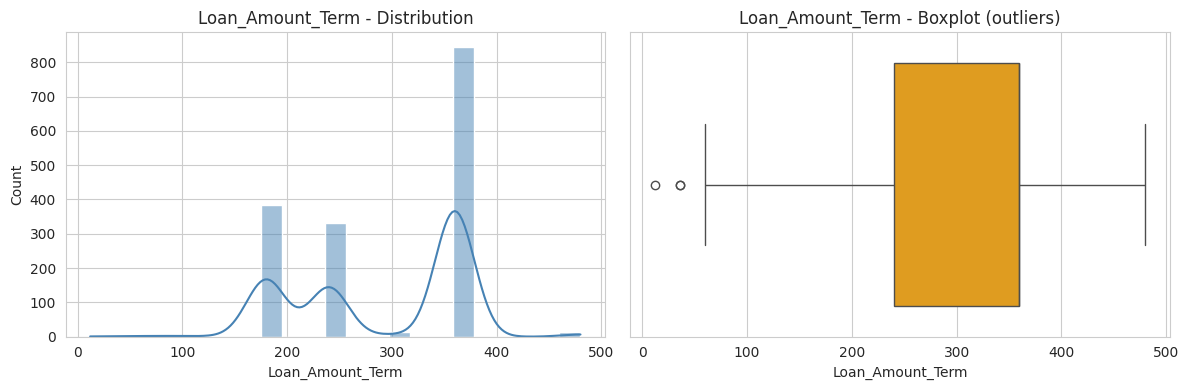

--- Loan Dataset | Column: Credit_History | dtype: float64 ---


count    1564.00000
mean        0.63555
std         0.48143
min         0.00000
25%         0.00000
50%         1.00000
75%         1.00000
max         1.00000
Name: Credit_History, dtype: float64

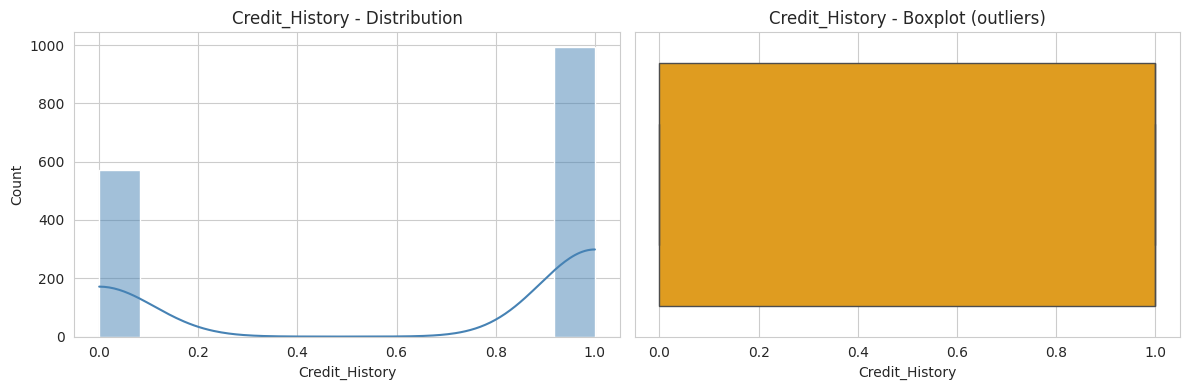

--- Loan Dataset | Column: Property_Area | dtype: str ---
Unique values: 3


Property_Area
Urban        549
Semiurban    545
Rural        520
Name: count, dtype: int64

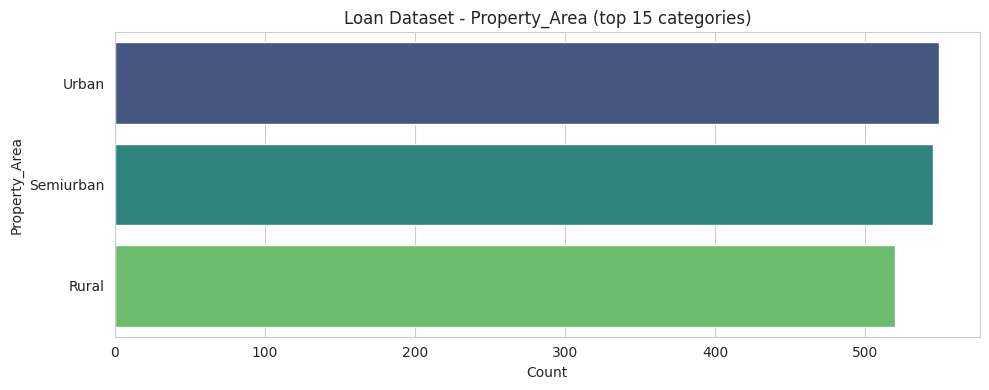

--- Loan Dataset | Column: Loan_Status | dtype: str ---
Unique values: 2


Loan_Status
Y    915
N    699
Name: count, dtype: int64

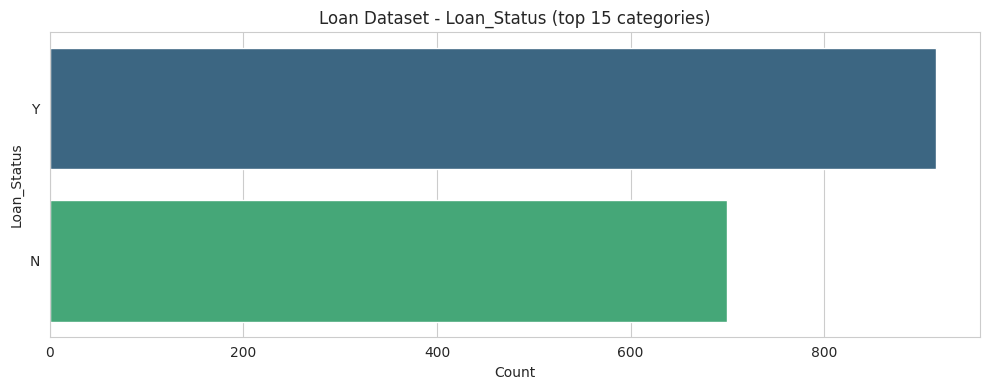

In [5]:
print("Loan_ID unique values:", loan_df['Loan_ID'].nunique(), "out of", len(loan_df), "rows")
analyze_every_column(loan_df.drop(columns=['Loan_ID']), "Loan Dataset")


## 1.4 Outlier Detection (IQR method, numeric columns)

In [6]:
loan_outliers = outlier_summary(loan_df, "Loan Dataset")

===== Loan Dataset: IQR Outlier Summary =====


,column,lower_bound,upper_bound,num_outliers
0,ApplicantIncome,-10688.375,27614.625,7
1,CoapplicantIncome,-6373.875,13253.125,4
3,Loan_Amount_Term,60.000,540.000,3
2,LoanAmount,-206.000,642.000,2
4,Credit_History,-1.500,2.500,0


## 1.5 Data Cleaning

Cleaning steps applied:
1. **Dependents**: convert `'3+'` to `3` and cast to numeric.
2. **Categorical missing values** (`Gender`, `Married`, `Dependents`, `Self_Employed`): impute with **mode**.
3. **Credit_History**: impute missing with **mode** (it is effectively categorical: 0/1).
4. **LoanAmount**: impute missing with **median** (robust to skew/outliers), then cap outliers using IQR bounds.
5. **Loan_Amount_Term**: impute missing with **mode** (a few standard term lengths dominate).
6. **Duplicates**: drop any exact duplicate rows.
7. Cast final dtypes appropriately.


In [7]:
loan_clean = loan_df.copy()

# 1. Fix Dependents encoding
loan_clean['Dependents'] = loan_clean['Dependents'].replace('3+', '3')
loan_clean['Dependents'] = pd.to_numeric(loan_clean['Dependents'], errors='coerce')

# 2. Impute categorical columns with mode
for col in ['Gender', 'Married', 'Self_Employed']:
    loan_clean[col] = loan_clean[col].fillna(loan_clean[col].mode()[0])

loan_clean['Dependents'] = loan_clean['Dependents'].fillna(loan_clean['Dependents'].mode()[0])

# 3. Credit_History -> mode
loan_clean['Credit_History'] = loan_clean['Credit_History'].fillna(loan_clean['Credit_History'].mode()[0])

# 4. LoanAmount -> median, then cap outliers (IQR)
loan_clean['LoanAmount'] = loan_clean['LoanAmount'].fillna(loan_clean['LoanAmount'].median())
q1, q3 = loan_clean['LoanAmount'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
loan_clean['LoanAmount'] = loan_clean['LoanAmount'].clip(lower, upper)

# 5. Loan_Amount_Term -> mode
loan_clean['Loan_Amount_Term'] = loan_clean['Loan_Amount_Term'].fillna(loan_clean['Loan_Amount_Term'].mode()[0])

# 6. Drop duplicates
before = loan_clean.shape[0]
loan_clean = loan_clean.drop_duplicates()
print(f"Dropped {before - loan_clean.shape[0]} duplicate rows")

# 7. Dtype fix
loan_clean['Dependents'] = loan_clean['Dependents'].astype(int)
loan_clean['Credit_History'] = loan_clean['Credit_History'].astype(int)

print("\nRemaining missing values after cleaning:")
print(loan_clean.isnull().sum().sum())
loan_clean.head()


Dropped 0 duplicate rows

Remaining missing values after cleaning:
0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,180.0,360.0,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,Y


## 1.6 Post-Cleaning Correlation Heatmap

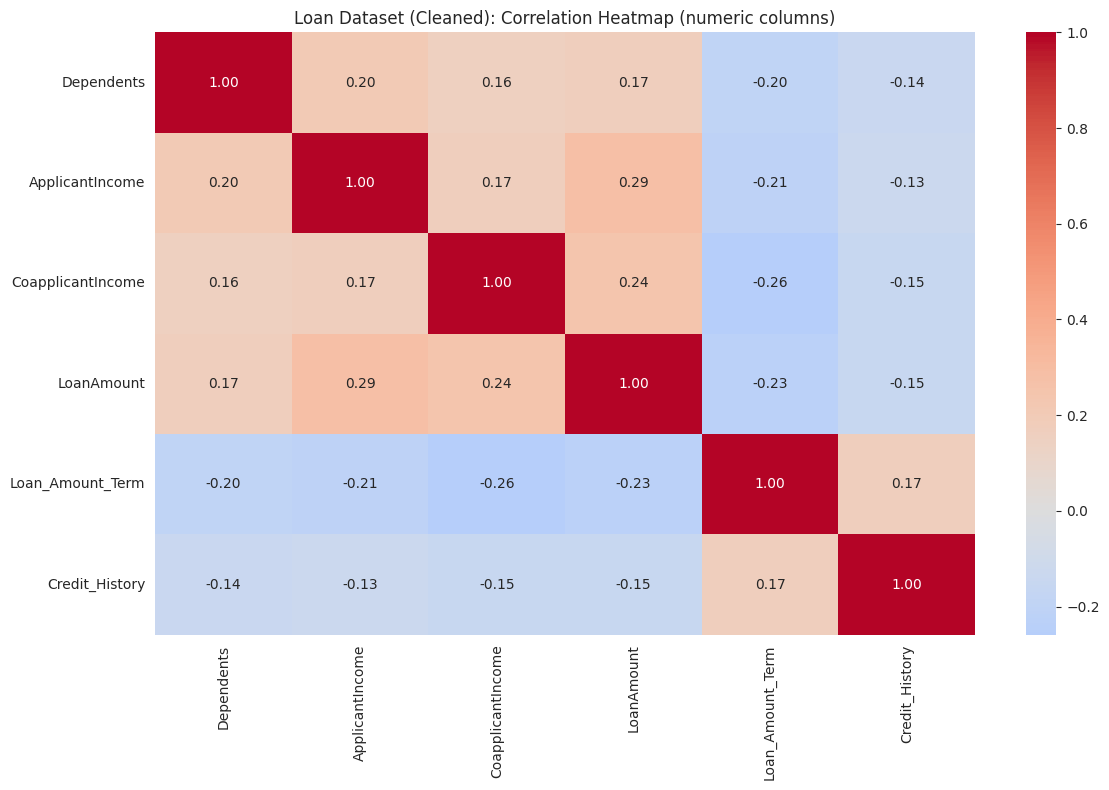

In [8]:
correlation_heatmap(loan_clean, "Loan Dataset (Cleaned)")

## 1.7 Target Variable Check (`Loan_Status`)

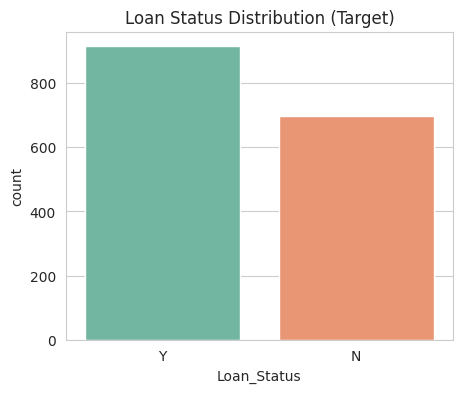

Loan_Status
Y    0.566914
N    0.433086
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='Loan_Status', data=loan_clean, palette='Set2')
plt.title("Loan Status Distribution (Target)")
plt.show()
print(loan_clean['Loan_Status'].value_counts(normalize=True))


## 1.8 Export Cleaned Dataset

In [10]:
loan_clean.to_csv('loan_train_cleaned.csv', index=False)
print("Saved: loan_train_cleaned.csv | shape:", loan_clean.shape)


Saved: loan_train_cleaned.csv | shape: (1614, 13)


---
# Dataset 2: Adult Census Income Dataset

Columns: `age, workclass, fnlwgt, education, educational-num, marital-status, occupation, relationship, race, gender, capital-gain, capital-loss, hours-per-week, native-country, income`

## 2.1 Load Data & Overview

Note: this dataset commonly encodes missing values as the string `'?'` rather than an empty cell, so we replace those with `NaN` on load.


In [11]:
adult_df = pd.read_csv('adult.csv')
adult_df = adult_df.replace('?', np.nan)
adult_miss = dataset_overview(adult_df, "Adult Dataset")


===== Adult Dataset : OVERVIEW =====


Shape: (48842, 15)

Column dtypes:
 age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object

First 5 rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Duplicate rows: 52

Missing values per column:


,missing_count,missing_pct
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


## 2.2 Missing Value Visualization

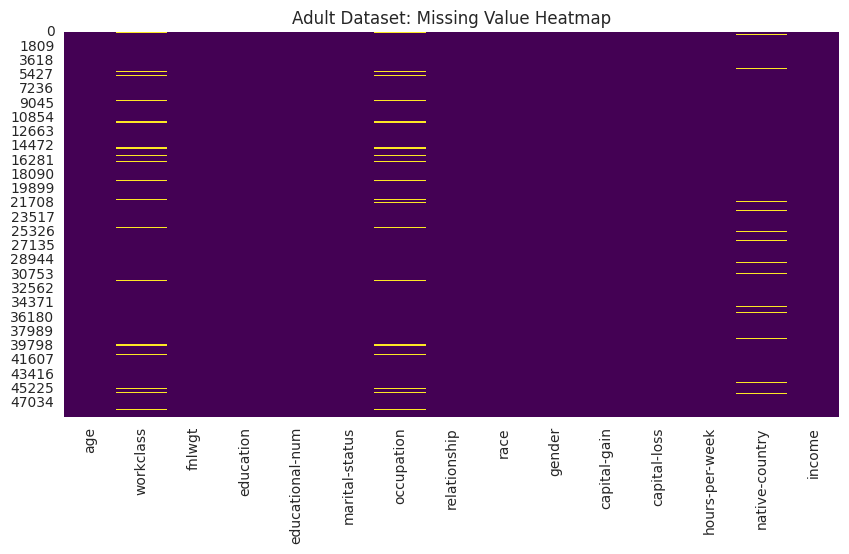

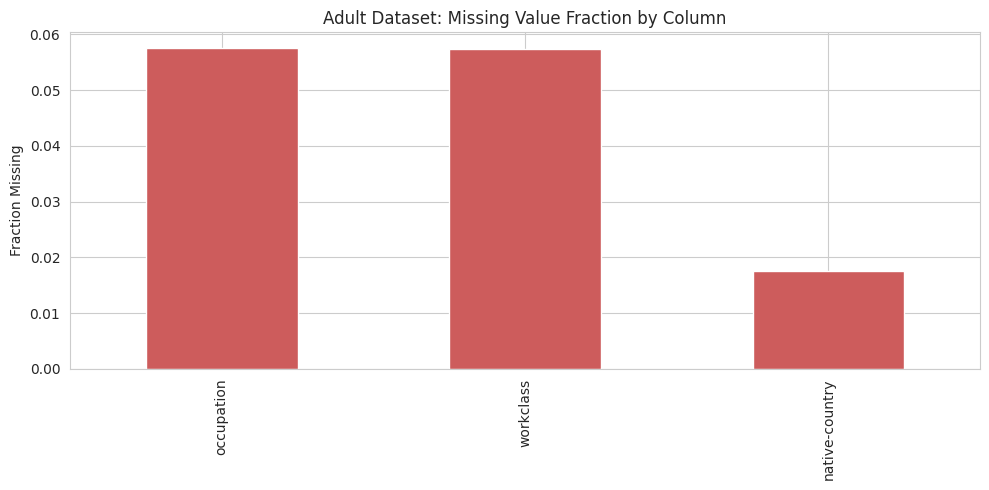

In [12]:
plot_missing(adult_df, "Adult Dataset")

## 2.3 Per-Column Analysis (every column)

--- Adult Dataset | Column: age | dtype: int64 ---


count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

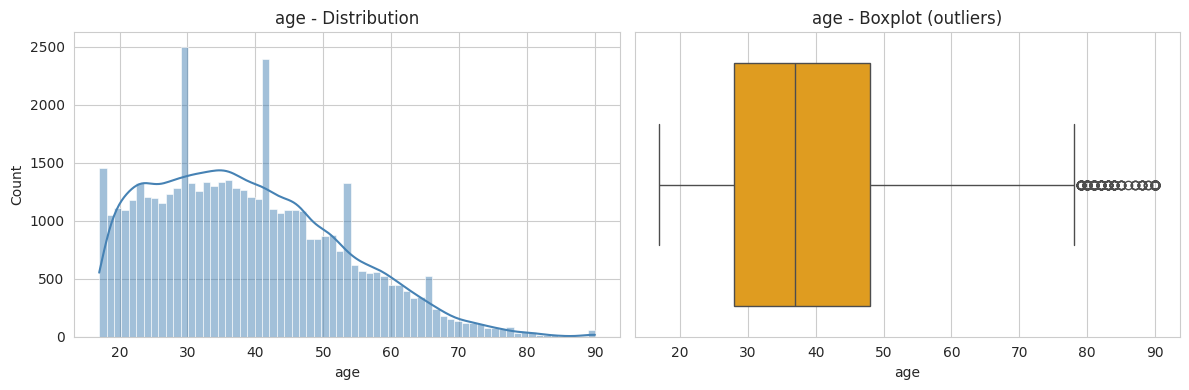

--- Adult Dataset | Column: workclass | dtype: str ---
Unique values: 8


workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

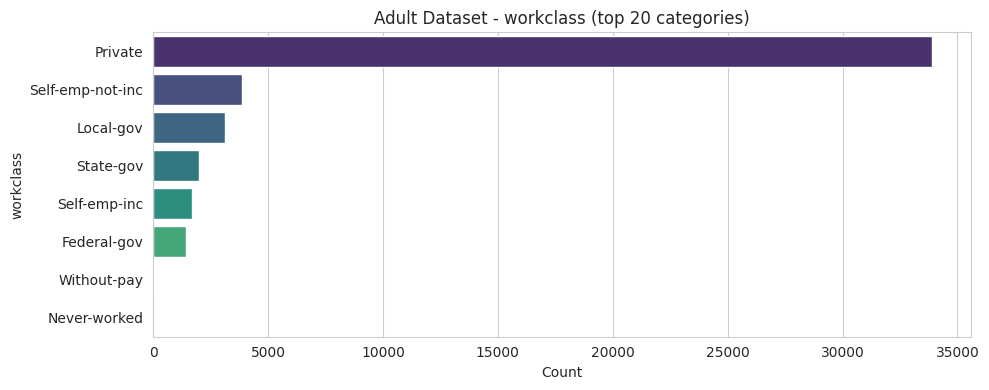

--- Adult Dataset | Column: fnlwgt | dtype: int64 ---


count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

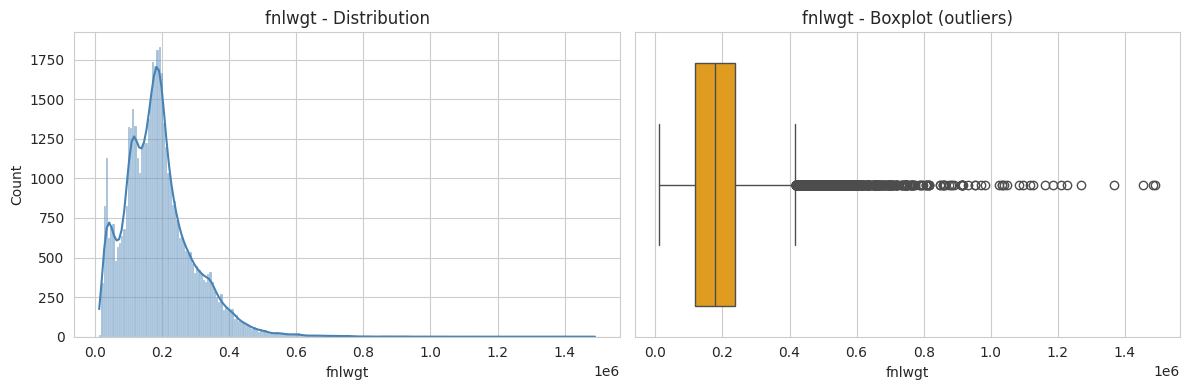

--- Adult Dataset | Column: education | dtype: str ---
Unique values: 16


education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

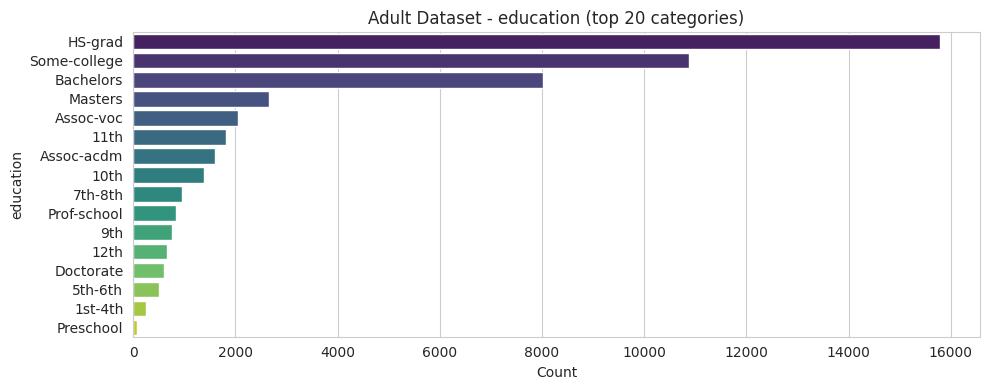

--- Adult Dataset | Column: educational-num | dtype: int64 ---


count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64

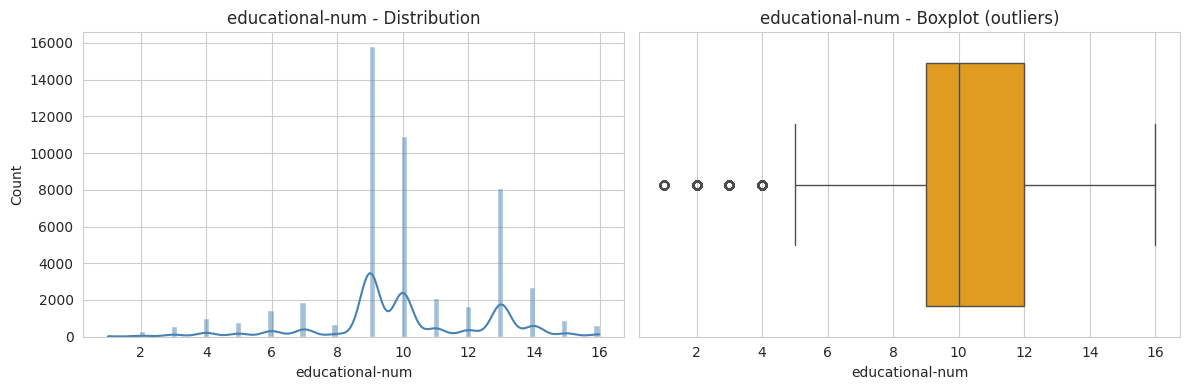

--- Adult Dataset | Column: marital-status | dtype: str ---
Unique values: 7


marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

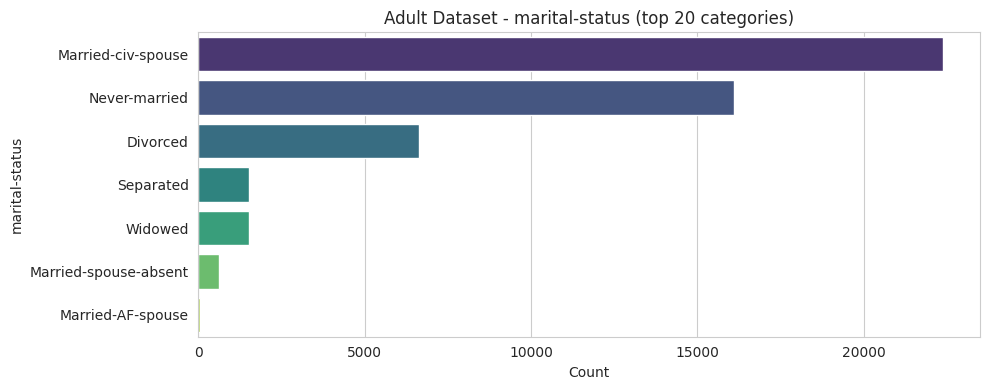

--- Adult Dataset | Column: occupation | dtype: str ---
Unique values: 14


occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

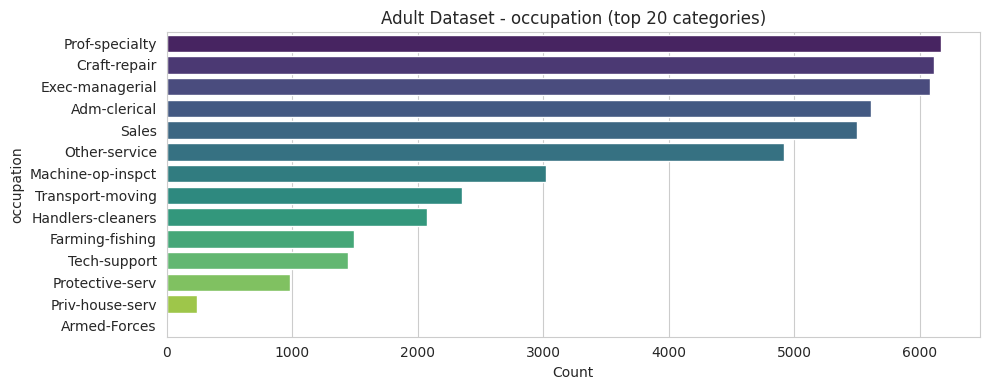

--- Adult Dataset | Column: relationship | dtype: str ---
Unique values: 6


relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

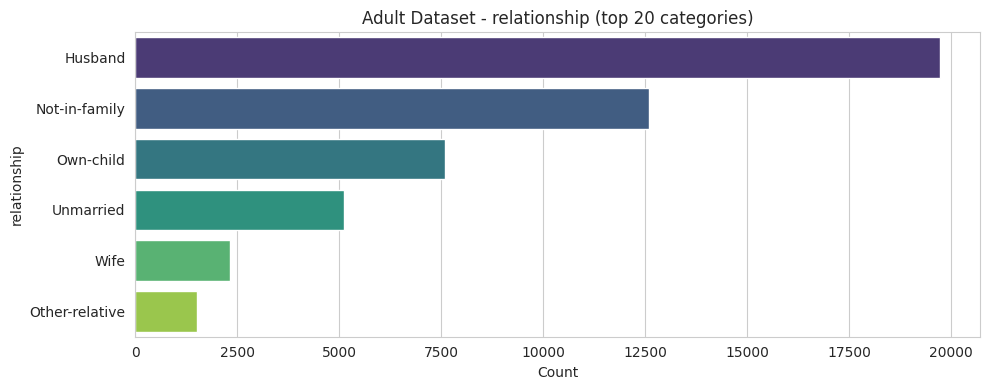

--- Adult Dataset | Column: race | dtype: str ---
Unique values: 5


race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

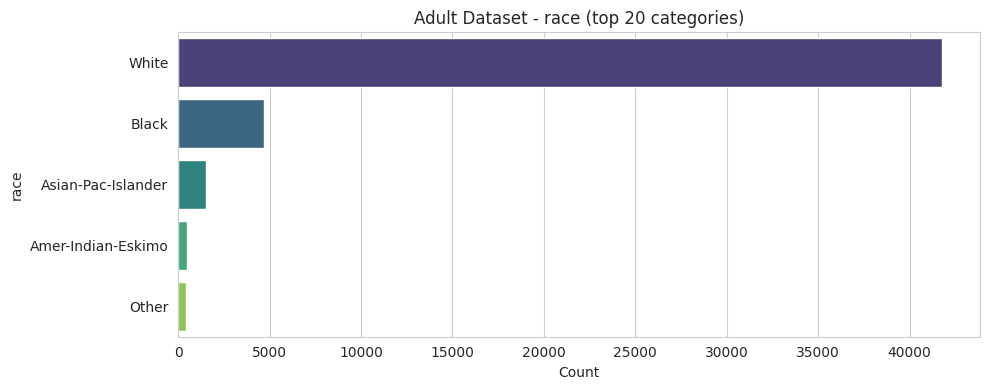

--- Adult Dataset | Column: gender | dtype: str ---
Unique values: 2


gender
Male      32650
Female    16192
Name: count, dtype: int64

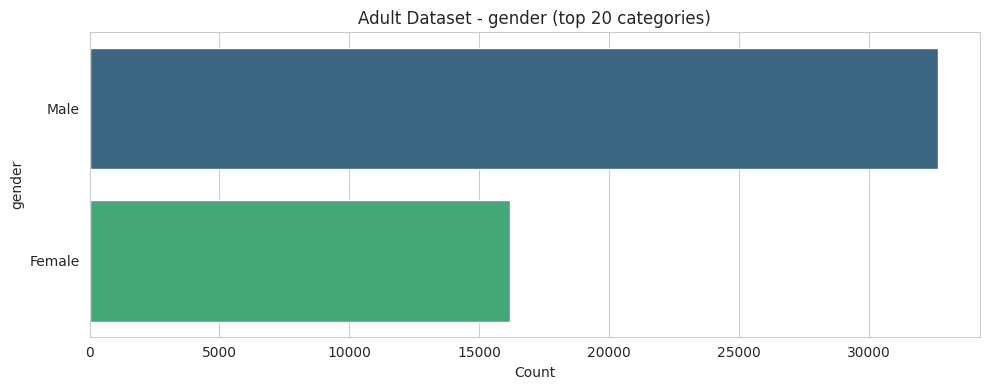

--- Adult Dataset | Column: capital-gain | dtype: int64 ---


count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

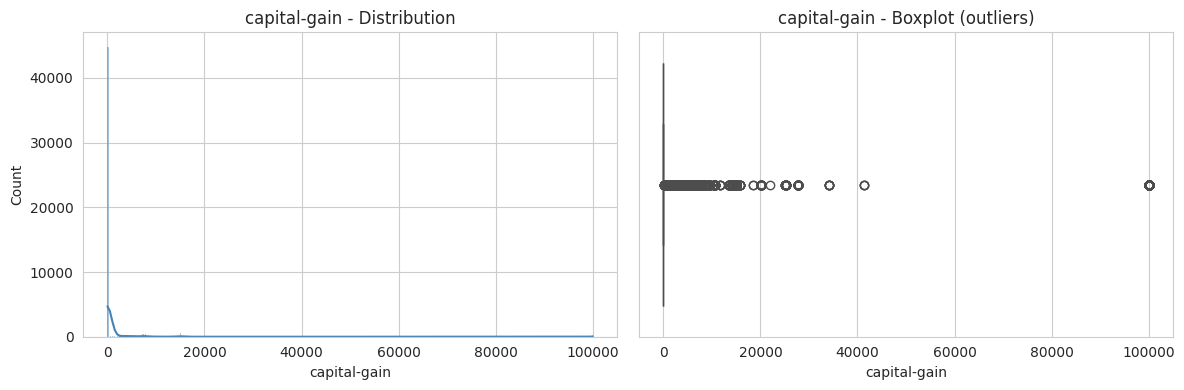

--- Adult Dataset | Column: capital-loss | dtype: int64 ---


count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

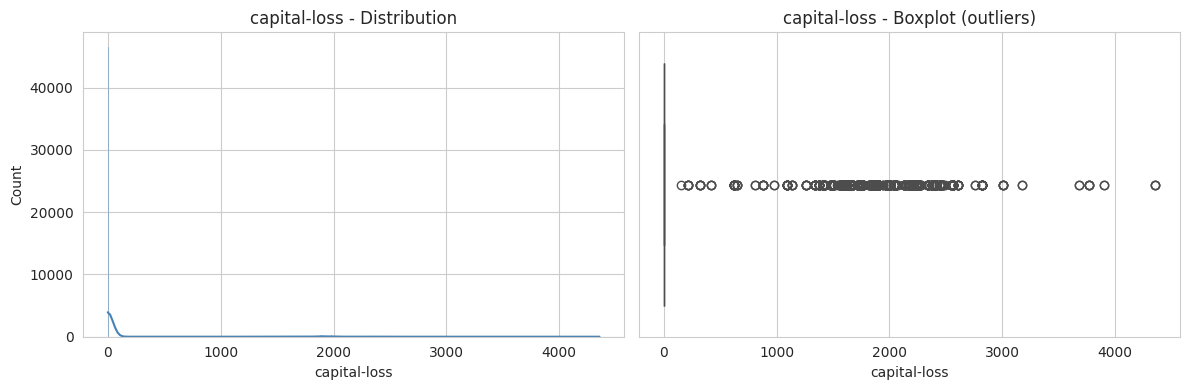

--- Adult Dataset | Column: hours-per-week | dtype: int64 ---


count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

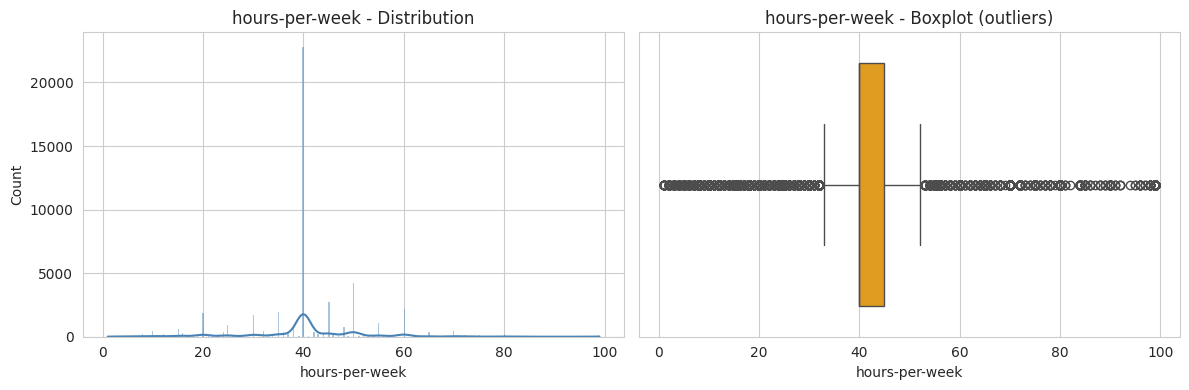

--- Adult Dataset | Column: native-country | dtype: str ---
Unique values: 41


native-country
United-States         43832
Mexico                  951
NaN                     857
Philippines             295
Germany                 206
Puerto-Rico             184
Canada                  182
El-Salvador             155
India                   151
Cuba                    138
England                 127
China                   122
South                   115
Jamaica                 106
Italy                   105
Dominican-Republic      103
Japan                    92
Guatemala                88
Poland                   87
Vietnam                  86
Name: count, dtype: int64

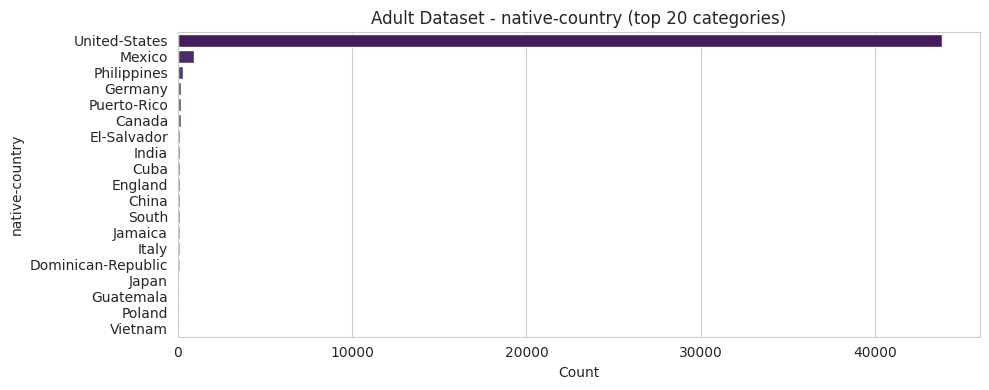

--- Adult Dataset | Column: income | dtype: str ---
Unique values: 2


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

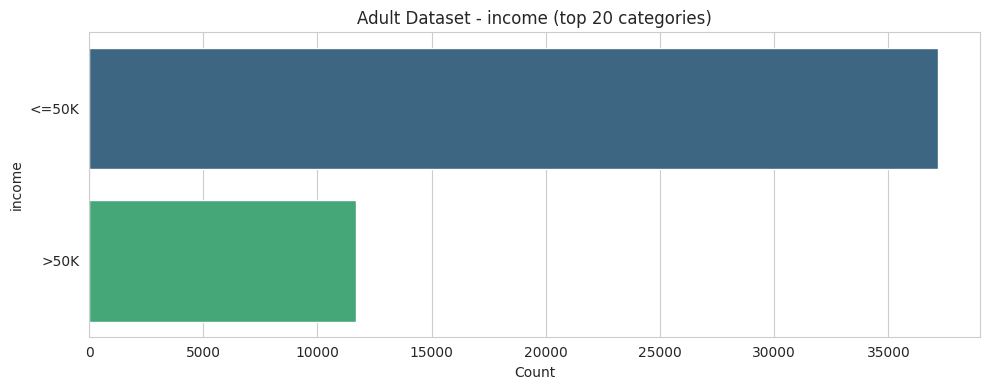

In [13]:
analyze_every_column(adult_df, "Adult Dataset", max_categories=20)

## 2.4 Outlier Detection (IQR method, numeric columns)

In [14]:
adult_outliers = outlier_summary(adult_df, "Adult Dataset")

===== Adult Dataset: IQR Outlier Summary =====


,column,lower_bound,upper_bound,num_outliers
5,hours-per-week,32.50,52.50,13496
3,capital-gain,0.00,0.00,4035
4,capital-loss,0.00,0.00,2282
2,educational-num,4.50,16.50,1794
1,fnlwgt,-62586.75,417779.25,1453
0,age,-2.00,78.00,216


## 2.5 Data Cleaning

Cleaning steps applied:
1. **`workclass`, `occupation`, `native-country`**: missing values (previously `'?'`) imputed with the column **mode**.
2. **`fnlwgt`**: this is a census sampling weight, not a real-world measurement — extreme values are expected and are *not* capped, but it is documented as such.
3. **`capital-gain` / `capital-loss`**: heavily zero-inflated; outliers are genuine (real capital gains/losses), so they are **kept but flagged**, not removed.
4. **`age` / `hours-per-week`**: capped at IQR bounds to control extreme outliers only.
5. **Duplicates**: dropped exact duplicate rows.
6. Whitespace stripped from all string/object columns.
7. `income` target standardized (some versions contain a trailing period, e.g. `<=50K.`).


In [15]:
adult_clean = adult_df.copy()

# 1. Strip whitespace from object columns
obj_cols = adult_clean.select_dtypes(include='object').columns
for col in obj_cols:
    adult_clean[col] = adult_clean[col].str.strip()

# 2. Impute missing categoricals with mode
for col in ['workclass', 'occupation', 'native-country']:
    adult_clean[col] = adult_clean[col].fillna(adult_clean[col].mode()[0])

# 3. Cap age & hours-per-week outliers (IQR) -- fnlwgt, capital-gain/loss intentionally left unmodified
for col in ['age', 'hours-per-week']:
    q1, q3 = adult_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    adult_clean[col] = adult_clean[col].clip(lower, upper)

# 4. Standardize income target (strip trailing periods if present)
adult_clean['income'] = adult_clean['income'].str.replace('.', '', regex=False).str.strip()

# 5. Drop duplicates
before = adult_clean.shape[0]
adult_clean = adult_clean.drop_duplicates()
print(f"Dropped {before - adult_clean.shape[0]} duplicate rows")

print("\nRemaining missing values after cleaning:")
print(adult_clean.isnull().sum().sum())
adult_clean.head()


Dropped 74 duplicate rows

Remaining missing values after cleaning:
0


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40.0,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50.0,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40.0,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,32.5,United-States,<=50K


## 2.6 Post-Cleaning Correlation Heatmap (numeric columns)

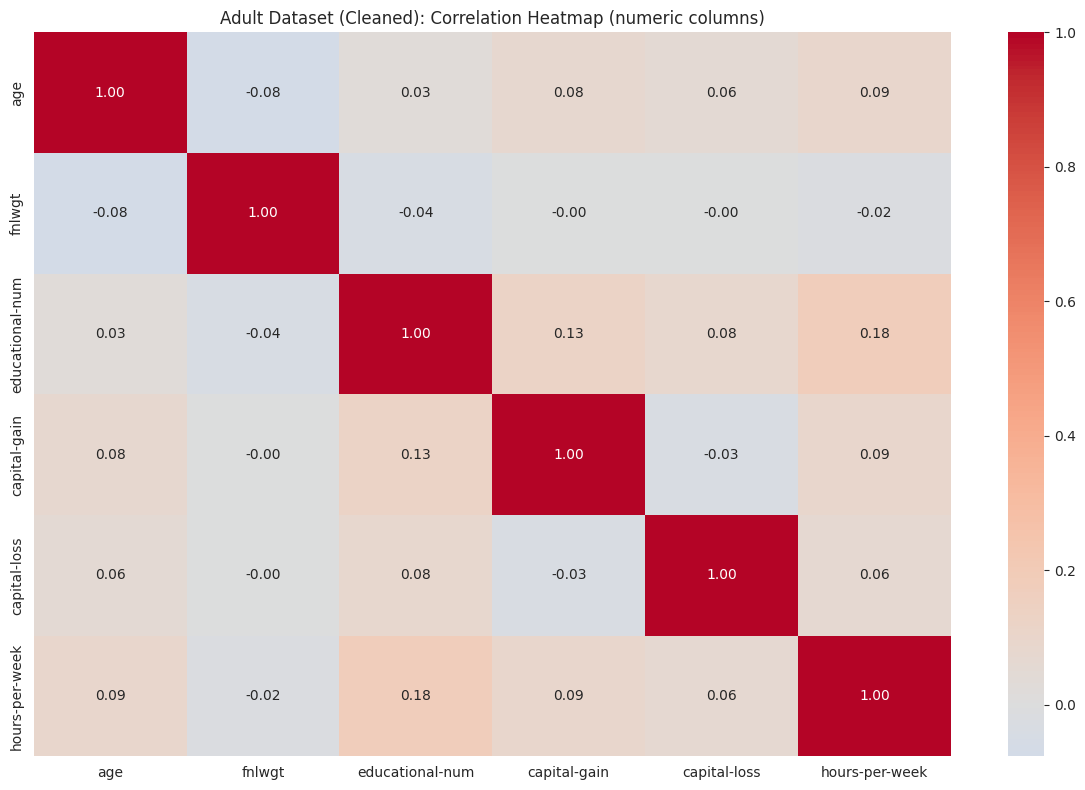

In [16]:
correlation_heatmap(adult_clean, "Adult Dataset (Cleaned)")

## 2.7 Target Variable Check (`income`) & Key Relationships

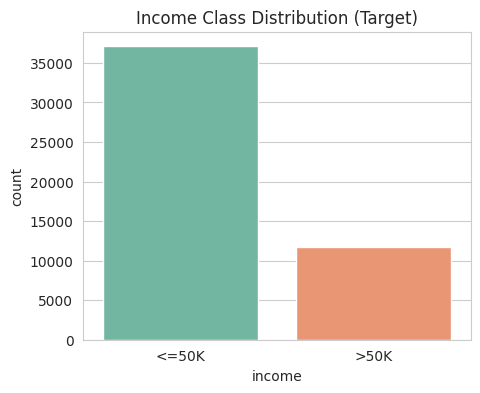

income
<=50K    0.760478
>50K     0.239522
Name: proportion, dtype: float64


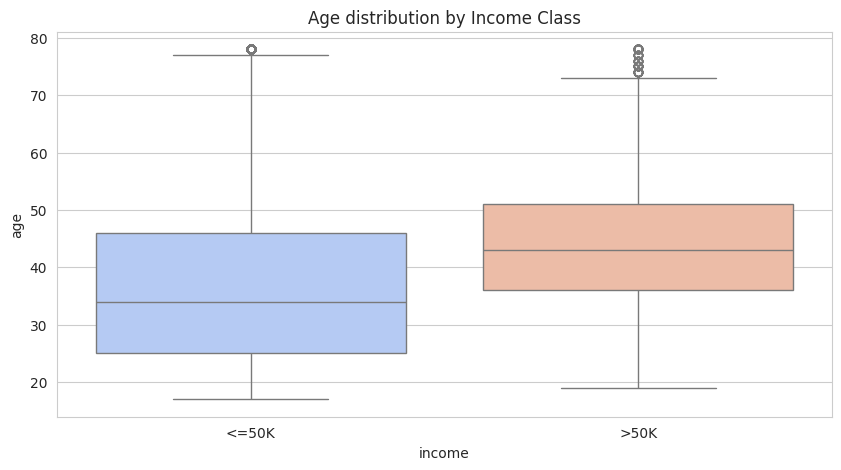

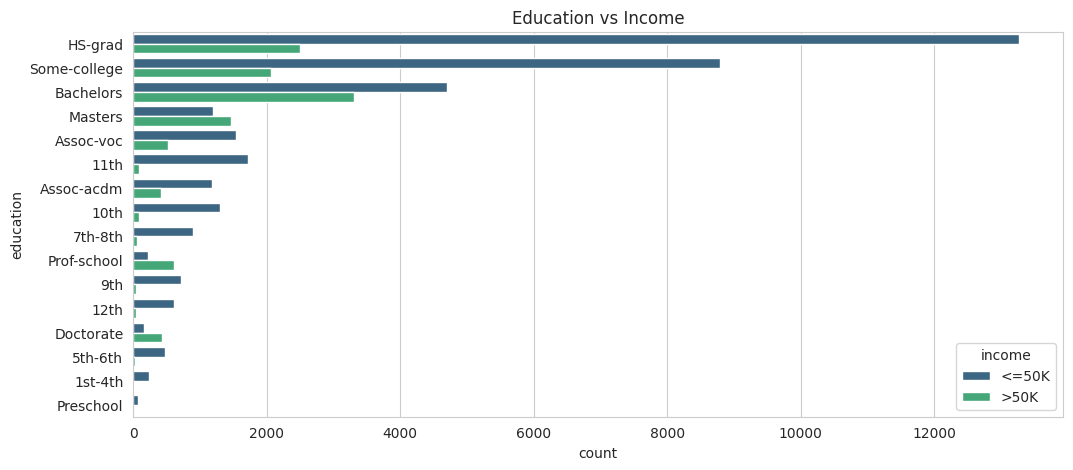

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x='income', data=adult_clean, palette='Set2')
plt.title("Income Class Distribution (Target)")
plt.show()
print(adult_clean['income'].value_counts(normalize=True))

plt.figure(figsize=(10,5))
sns.boxplot(x='income', y='age', data=adult_clean, palette='coolwarm')
plt.title("Age distribution by Income Class")
plt.show()

plt.figure(figsize=(12,5))
top_edu = adult_clean['education'].value_counts().index
sns.countplot(y='education', hue='income', data=adult_clean, order=top_edu, palette='viridis')
plt.title("Education vs Income")
plt.show()


## 2.8 Export Cleaned Dataset

In [18]:
adult_clean.to_csv('adult_cleaned.csv', index=False)
print("Saved: adult_cleaned.csv | shape:", adult_clean.shape)


Saved: adult_cleaned.csv | shape: (48768, 15)


---
# Dataset 3: Hotel Booking Dataset

36 columns covering booking details, guest info, and (importantly) **PII columns** (`name`, `email`, `phone-number`, `credit_card`) which will be handled with special care during cleaning.

## 3.1 Load Data & Overview


In [19]:
hotel_df = pd.read_csv('hotel_booking.csv')
hotel_miss = dataset_overview(hotel_df, "Hotel Booking Dataset")


===== Hotel Booking Dataset : OVERVIEW =====
Shape: (119390, 36)

Column dtypes:
 hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498



Duplicate rows: 0

Missing values per column:


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


## 3.2 Missing Value Visualization

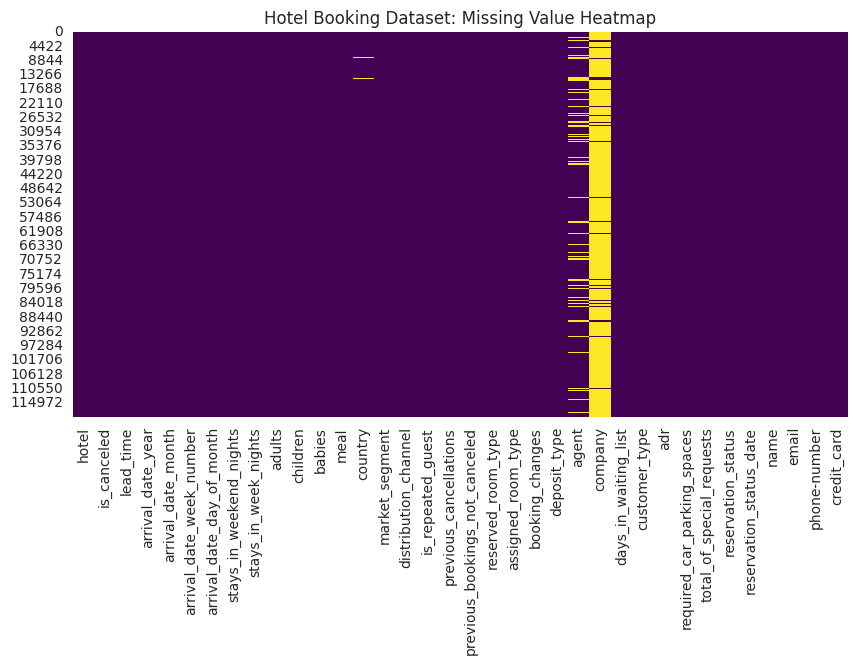

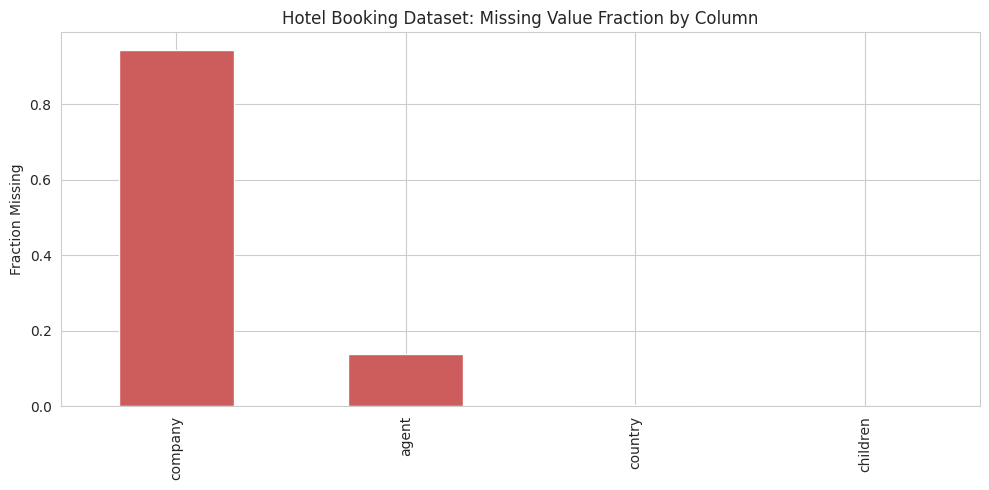

In [20]:
plot_missing(hotel_df, "Hotel Booking Dataset")

## 3.3 Per-Column Analysis (every column)

The dataset has 36 columns including 4 PII columns (`name`, `email`, `phone-number`, `credit_card`) which are high-cardinality identifiers with no distributional meaning for EDA — they are excluded from the plotting loop but retained in the missing-value/overview checks above, and will be **dropped entirely during cleaning** for privacy.


--- Hotel Booking Dataset | Column: hotel | dtype: str ---
Unique values: 2


hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

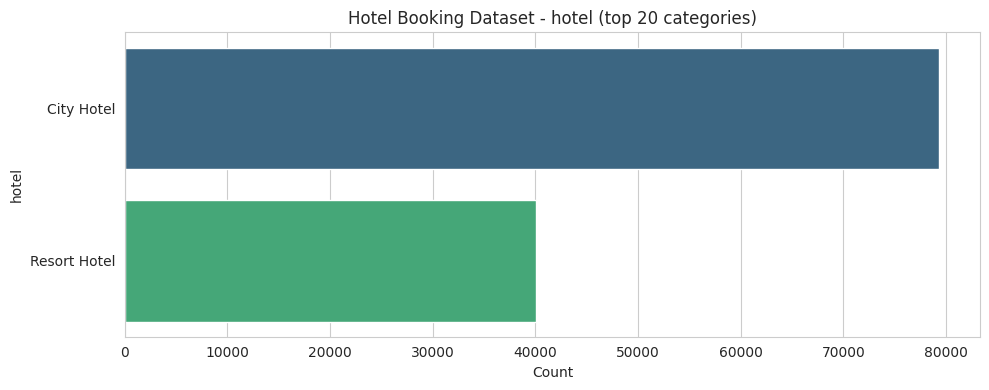

--- Hotel Booking Dataset | Column: is_canceled | dtype: int64 ---


count    119390.000000
mean          0.370416
std           0.482918
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: is_canceled, dtype: float64

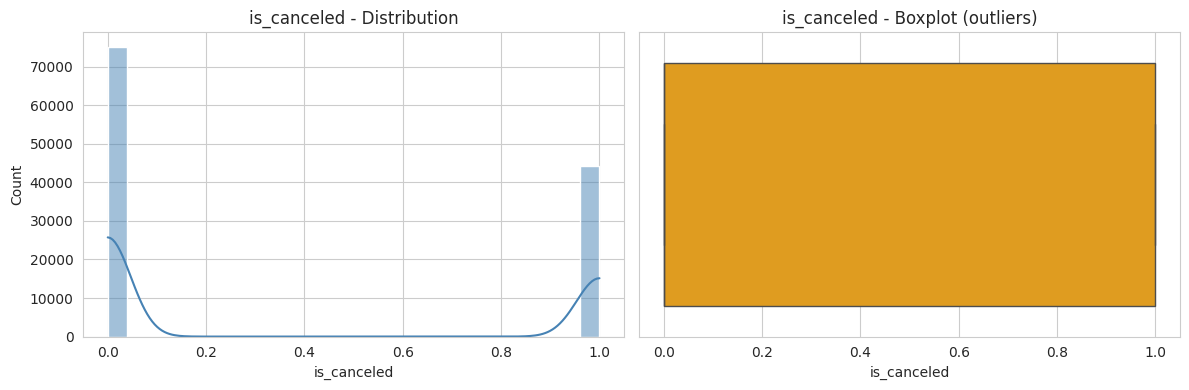

--- Hotel Booking Dataset | Column: lead_time | dtype: int64 ---


count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

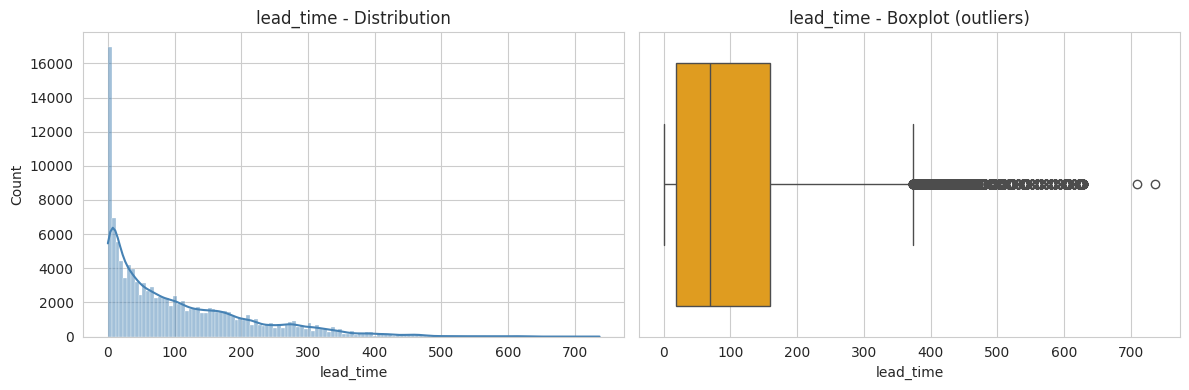

--- Hotel Booking Dataset | Column: arrival_date_year | dtype: int64 ---


count    119390.000000
mean       2016.156554
std           0.707476
min        2015.000000
25%        2016.000000
50%        2016.000000
75%        2017.000000
max        2017.000000
Name: arrival_date_year, dtype: float64

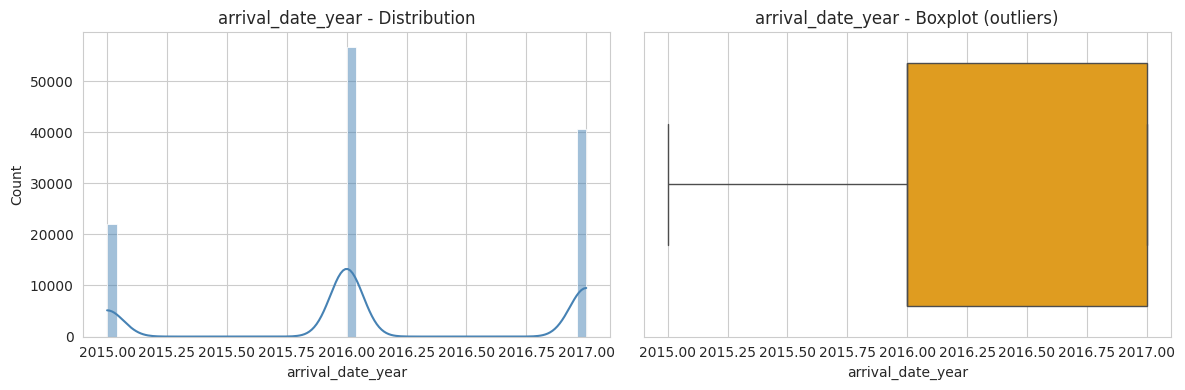

--- Hotel Booking Dataset | Column: arrival_date_month | dtype: str ---
Unique values: 12


arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

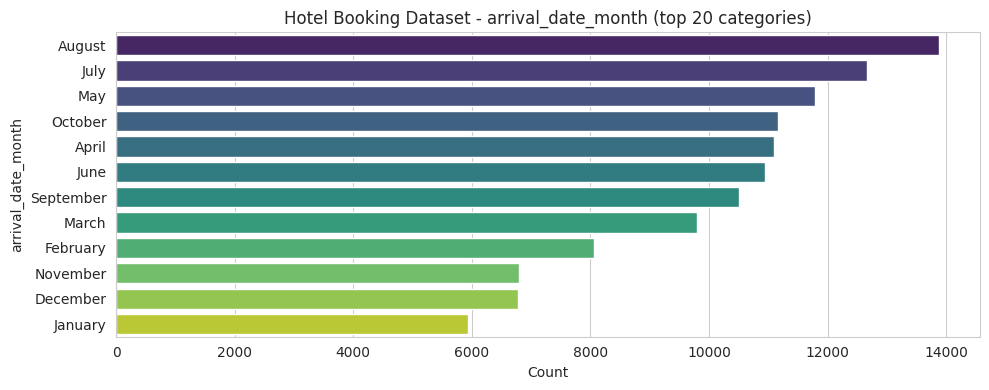

--- Hotel Booking Dataset | Column: arrival_date_week_number | dtype: int64 ---


count    119390.000000
mean         27.165173
std          13.605138
min           1.000000
25%          16.000000
50%          28.000000
75%          38.000000
max          53.000000
Name: arrival_date_week_number, dtype: float64

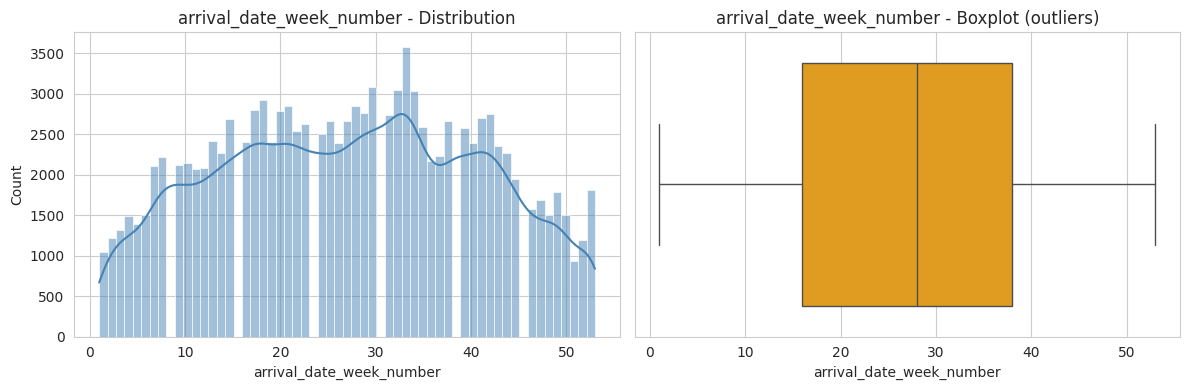

--- Hotel Booking Dataset | Column: arrival_date_day_of_month | dtype: int64 ---


count    119390.000000
mean         15.798241
std           8.780829
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: arrival_date_day_of_month, dtype: float64

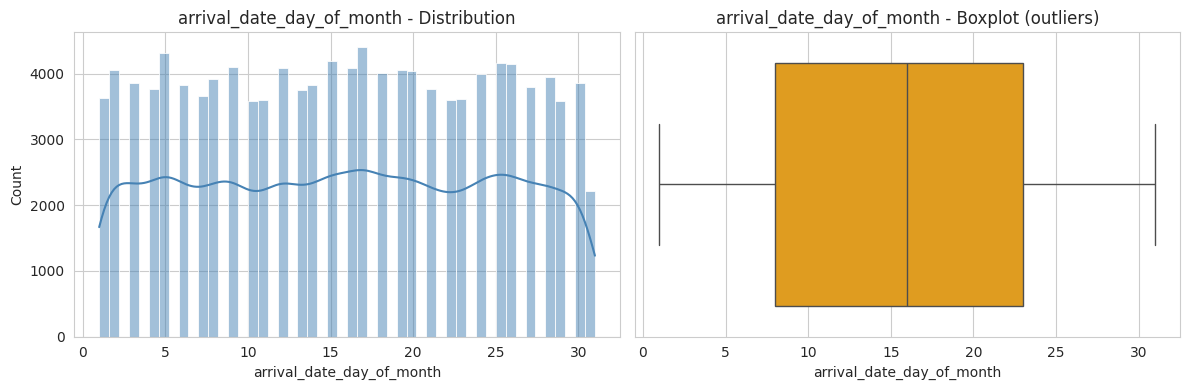

--- Hotel Booking Dataset | Column: stays_in_weekend_nights | dtype: int64 ---


count    119390.000000
mean          0.927599
std           0.998613
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          19.000000
Name: stays_in_weekend_nights, dtype: float64

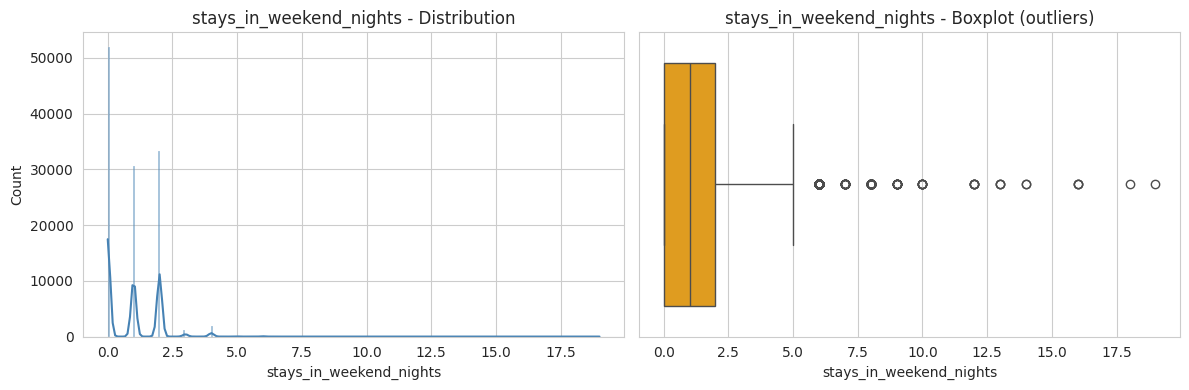

--- Hotel Booking Dataset | Column: stays_in_week_nights | dtype: int64 ---


count    119390.000000
mean          2.500302
std           1.908286
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          50.000000
Name: stays_in_week_nights, dtype: float64

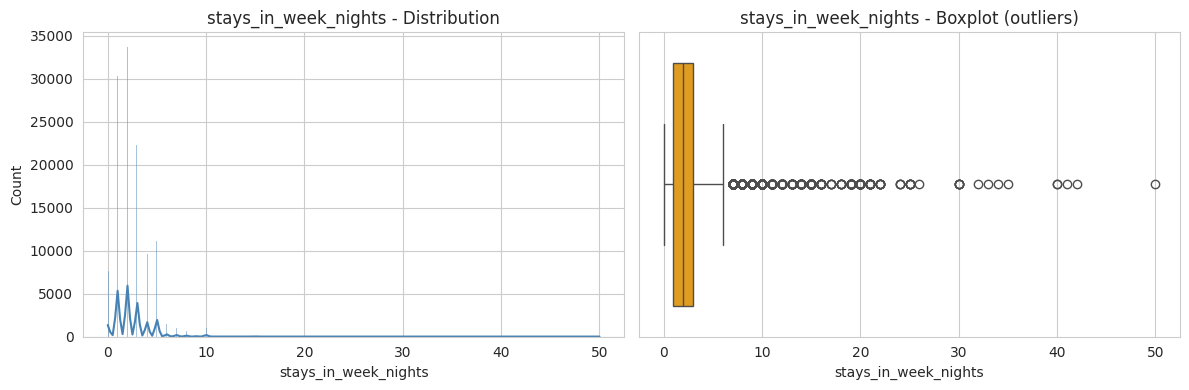

--- Hotel Booking Dataset | Column: adults | dtype: int64 ---


count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64

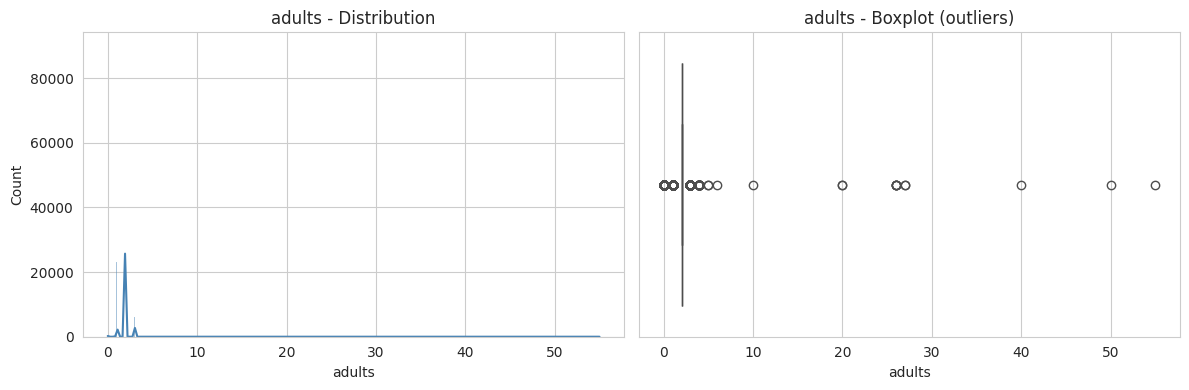

--- Hotel Booking Dataset | Column: children | dtype: float64 ---


count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64

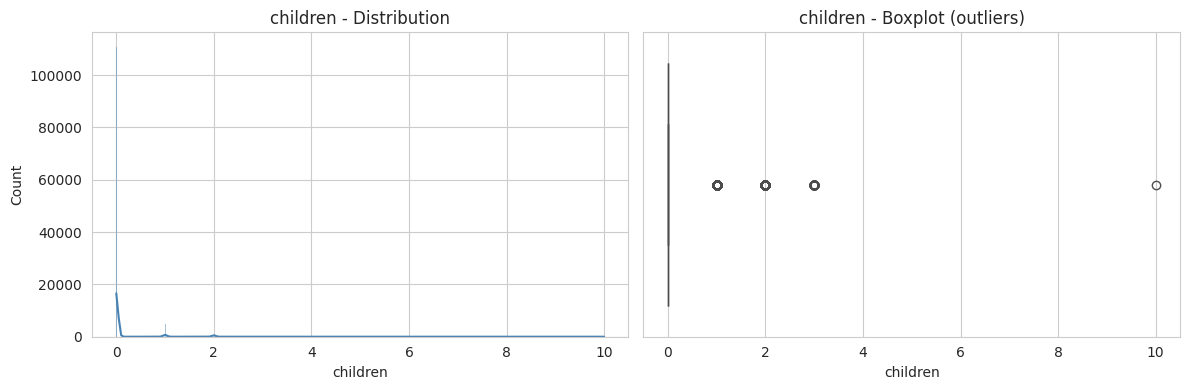

--- Hotel Booking Dataset | Column: babies | dtype: int64 ---


count    119390.000000
mean          0.007949
std           0.097436
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: babies, dtype: float64

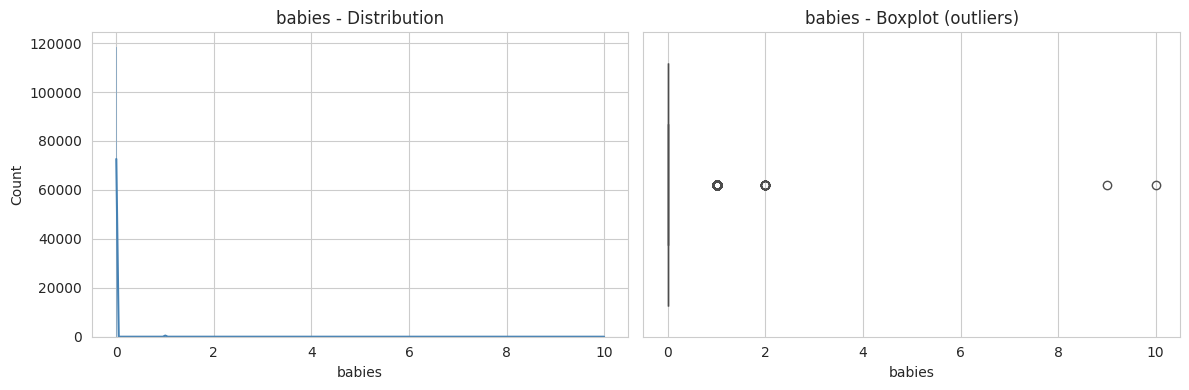

--- Hotel Booking Dataset | Column: meal | dtype: str ---
Unique values: 5


meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

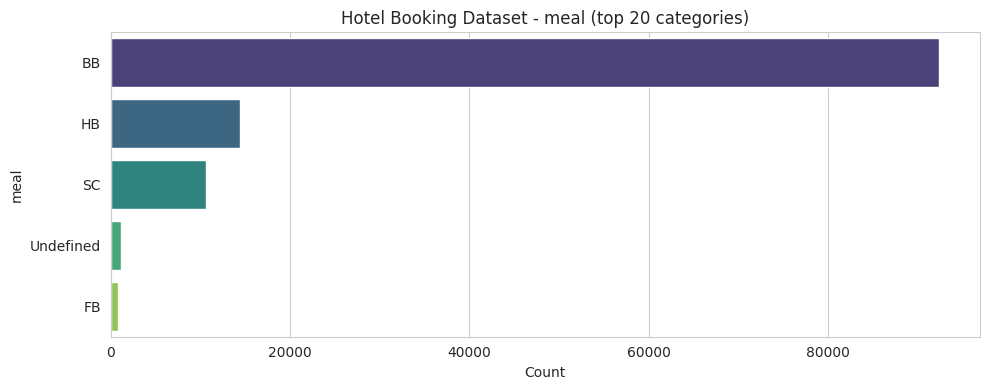

--- Hotel Booking Dataset | Column: country | dtype: str ---
Unique values: 177


country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: count, dtype: int64

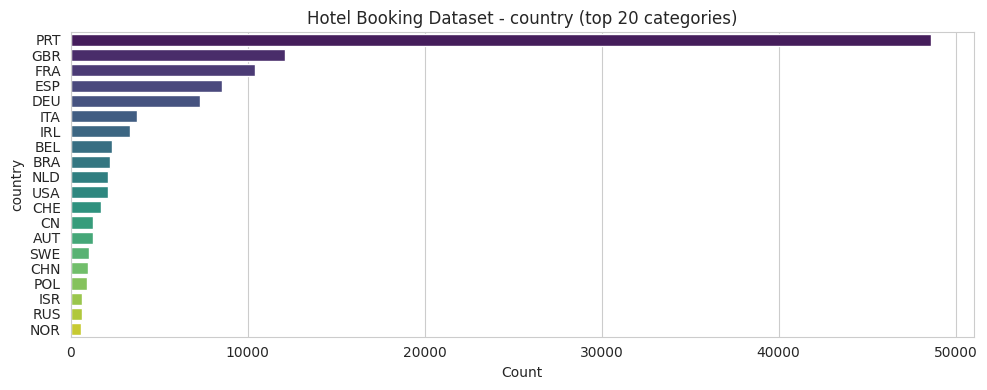

--- Hotel Booking Dataset | Column: market_segment | dtype: str ---
Unique values: 8


market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

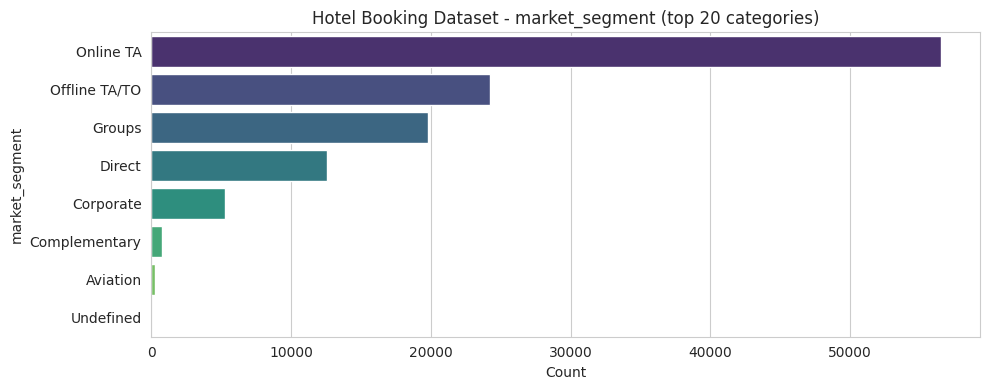

--- Hotel Booking Dataset | Column: distribution_channel | dtype: str ---
Unique values: 5


distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

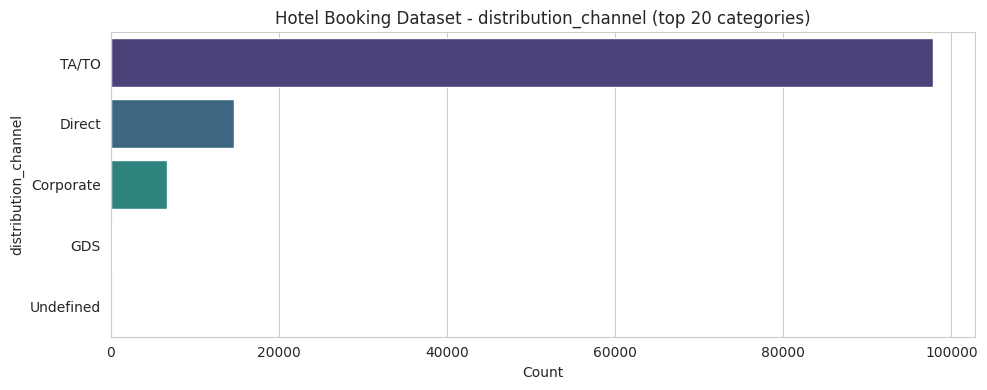

--- Hotel Booking Dataset | Column: is_repeated_guest | dtype: int64 ---


count    119390.000000
mean          0.031912
std           0.175767
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: is_repeated_guest, dtype: float64

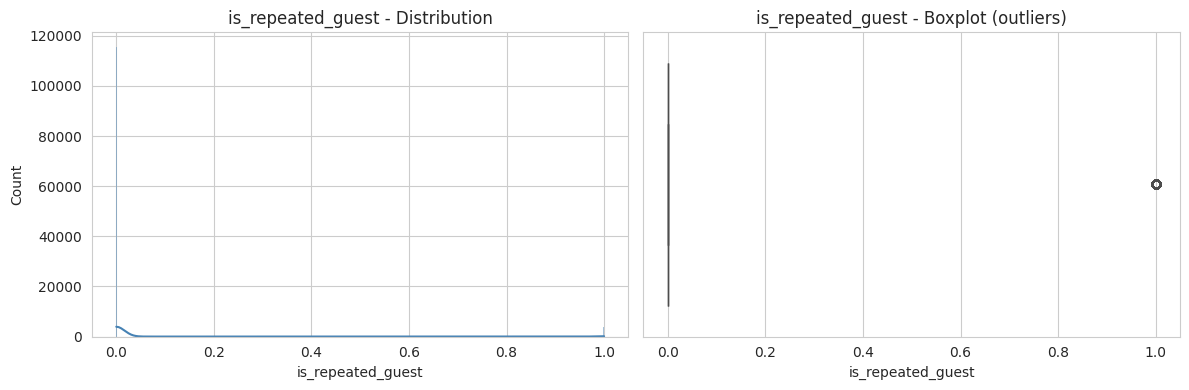

--- Hotel Booking Dataset | Column: previous_cancellations | dtype: int64 ---


count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64

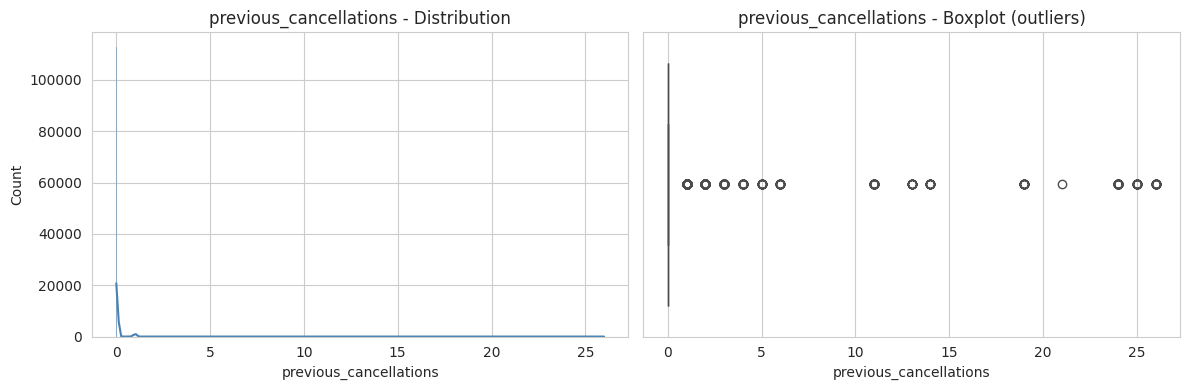

--- Hotel Booking Dataset | Column: previous_bookings_not_canceled | dtype: int64 ---


count    119390.000000
mean          0.137097
std           1.497437
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          72.000000
Name: previous_bookings_not_canceled, dtype: float64

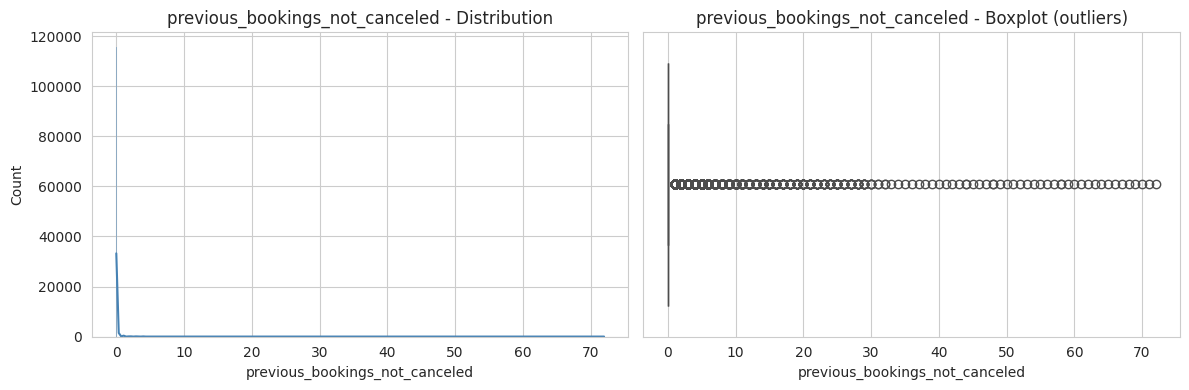

--- Hotel Booking Dataset | Column: reserved_room_type | dtype: str ---
Unique values: 10


reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64

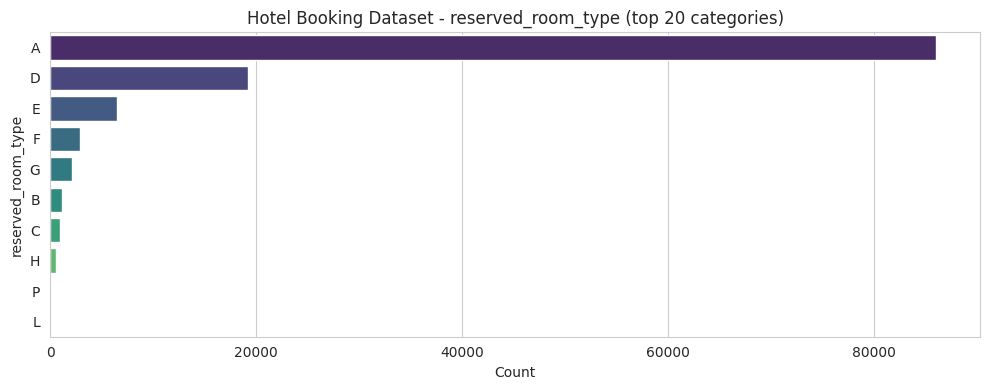

--- Hotel Booking Dataset | Column: assigned_room_type | dtype: str ---
Unique values: 12


assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64

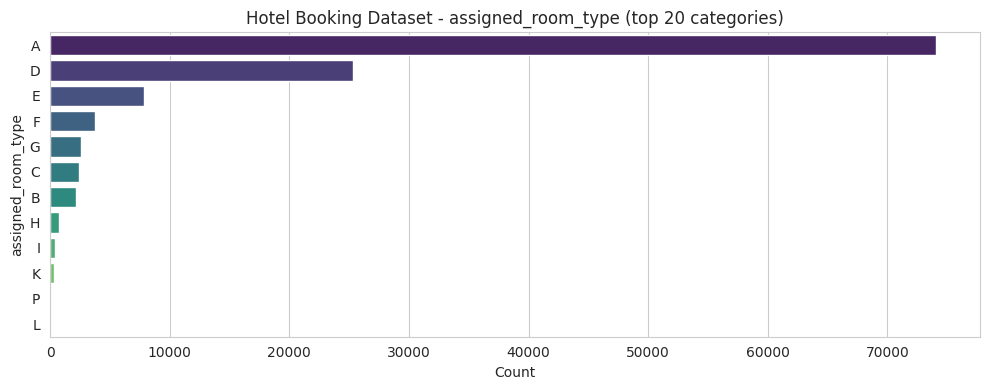

--- Hotel Booking Dataset | Column: booking_changes | dtype: int64 ---


count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64

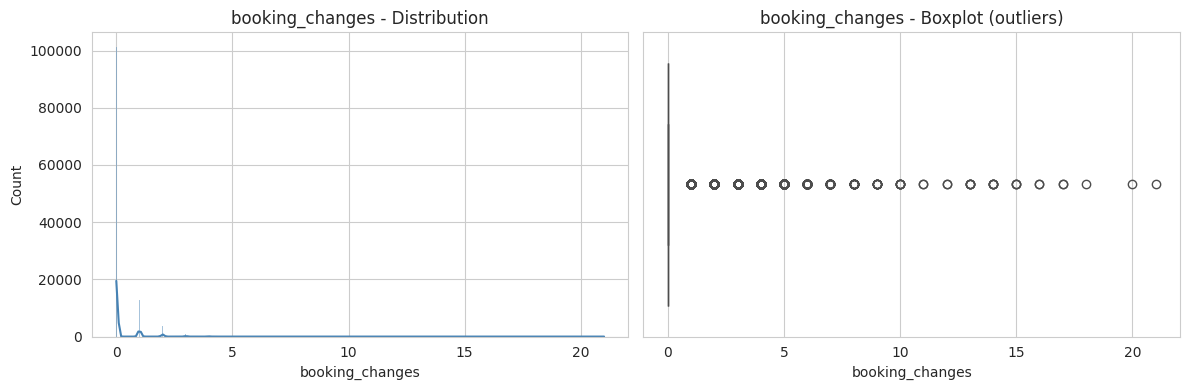

--- Hotel Booking Dataset | Column: deposit_type | dtype: str ---
Unique values: 3


deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

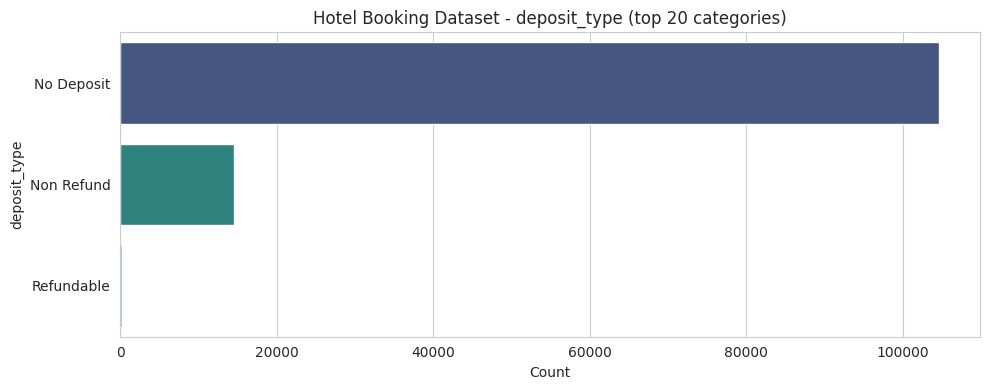

--- Hotel Booking Dataset | Column: agent | dtype: float64 ---


count    103050.000000
mean         86.693382
std         110.774548
min           1.000000
25%           9.000000
50%          14.000000
75%         229.000000
max         535.000000
Name: agent, dtype: float64

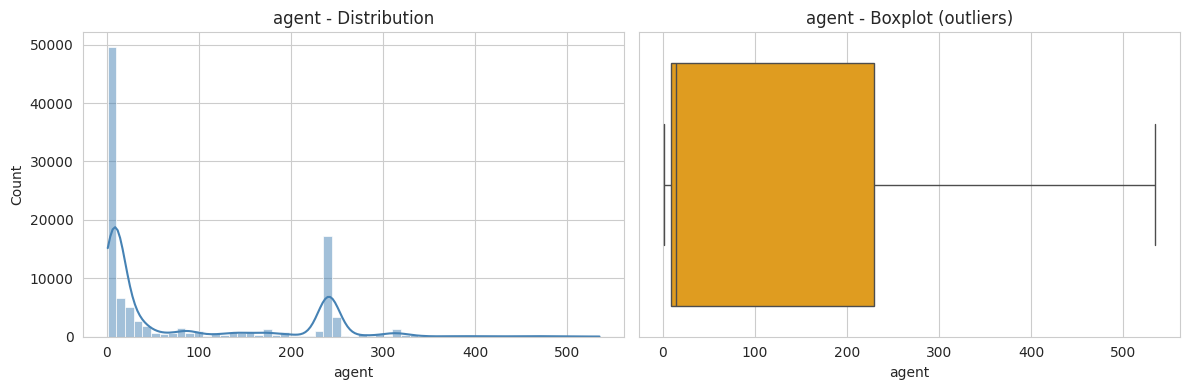

--- Hotel Booking Dataset | Column: company | dtype: float64 ---


count    6797.000000
mean      189.266735
std       131.655015
min         6.000000
25%        62.000000
50%       179.000000
75%       270.000000
max       543.000000
Name: company, dtype: float64

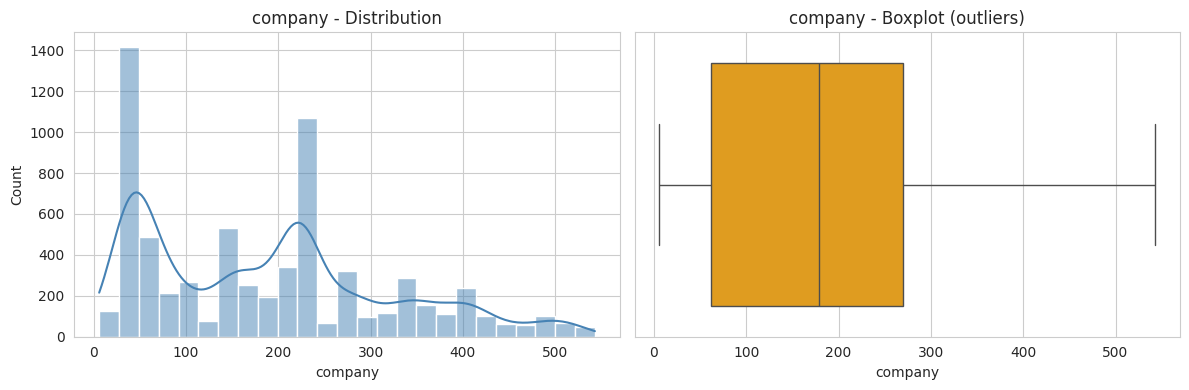

--- Hotel Booking Dataset | Column: days_in_waiting_list | dtype: int64 ---


count    119390.000000
mean          2.321149
std          17.594721
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64

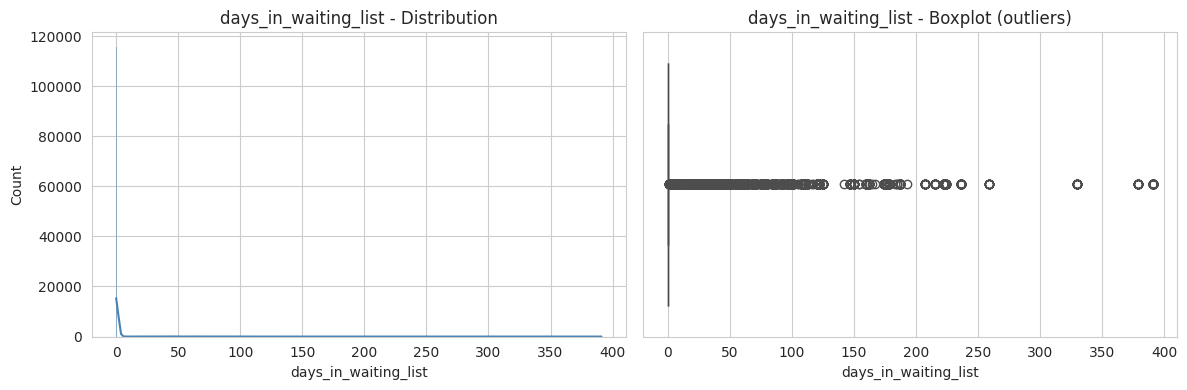

--- Hotel Booking Dataset | Column: customer_type | dtype: str ---
Unique values: 4


customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

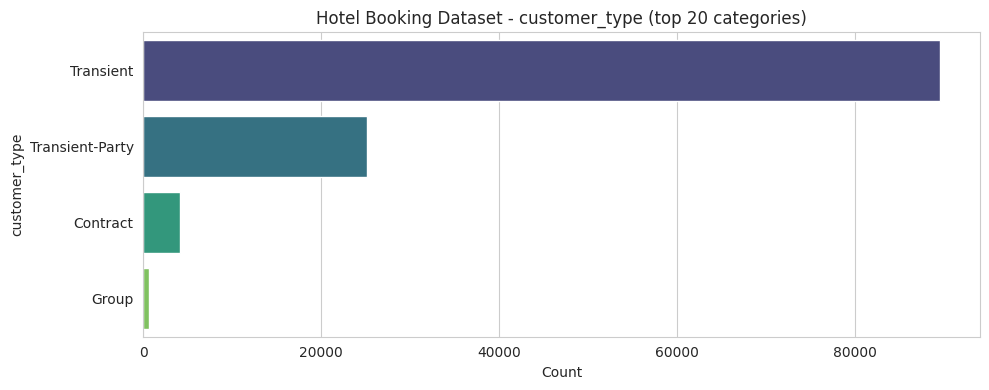

--- Hotel Booking Dataset | Column: adr | dtype: float64 ---


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

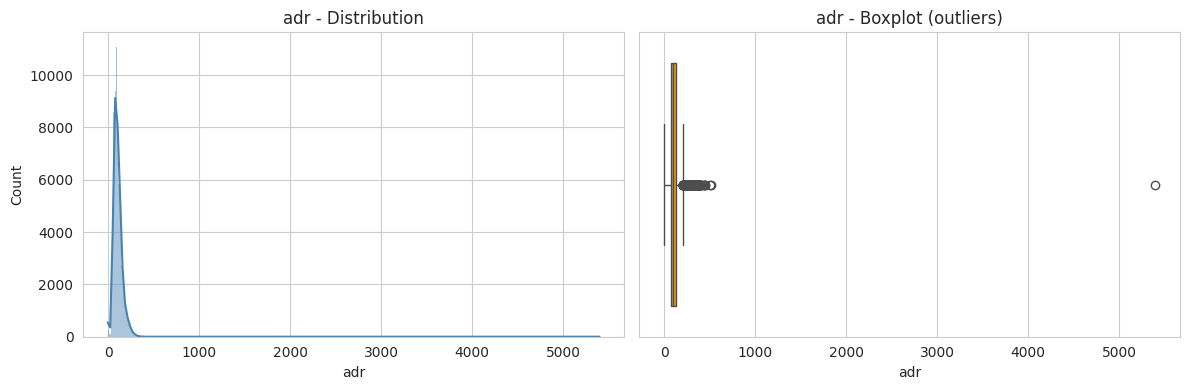

--- Hotel Booking Dataset | Column: required_car_parking_spaces | dtype: int64 ---


count    119390.000000
mean          0.062518
std           0.245291
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: required_car_parking_spaces, dtype: float64

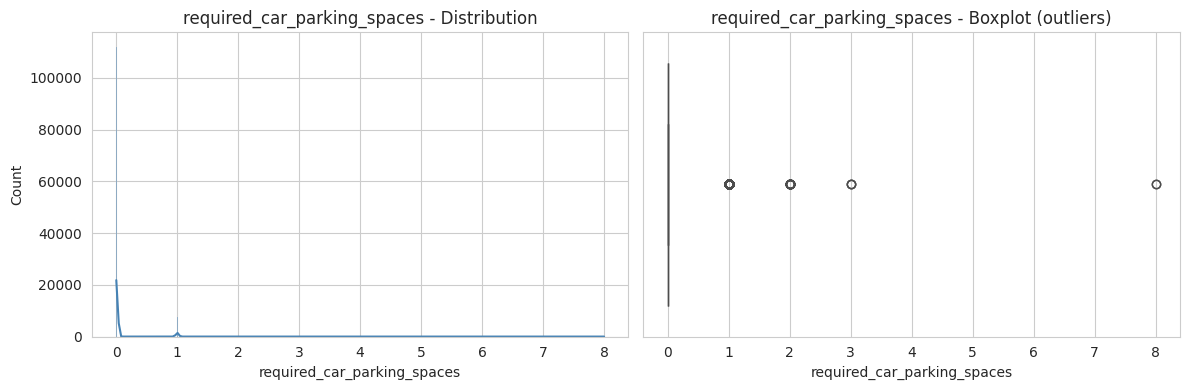

--- Hotel Booking Dataset | Column: total_of_special_requests | dtype: int64 ---


count    119390.000000
mean          0.571363
std           0.792798
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           5.000000
Name: total_of_special_requests, dtype: float64

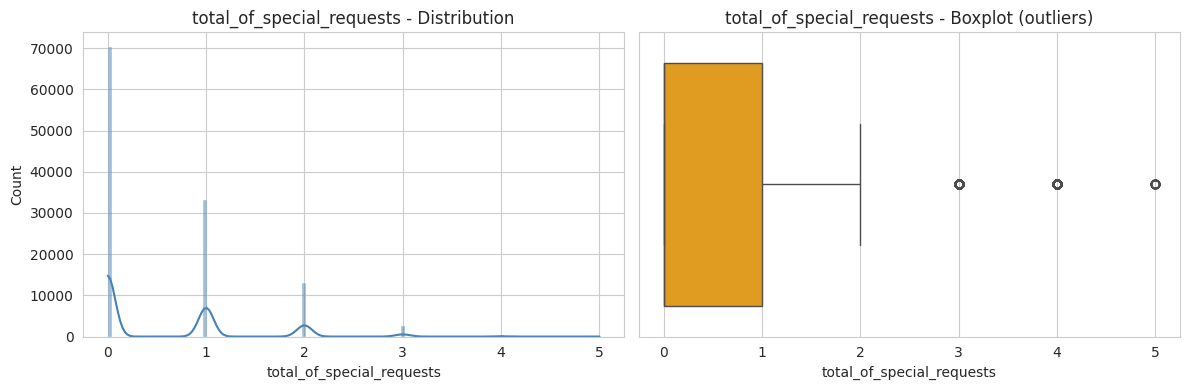

--- Hotel Booking Dataset | Column: reservation_status | dtype: str ---
Unique values: 3


reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

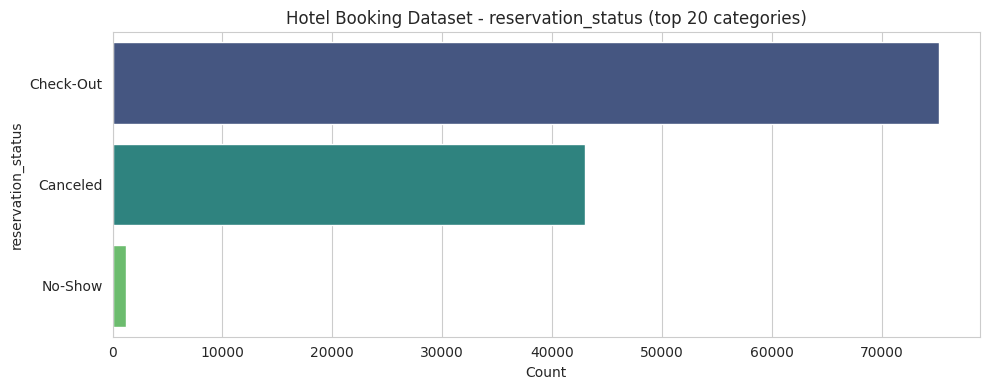

--- Hotel Booking Dataset | Column: reservation_status_date | dtype: str ---
Unique values: 926


reservation_status_date
2015-10-21    1461
2015-07-06     805
2016-11-25     790
2015-01-01     763
2016-01-18     625
2015-07-02     469
2016-12-07     450
2015-12-18     423
2016-02-09     412
2016-04-04     382
2017-01-24     343
2016-11-21     340
2016-03-15     329
2017-01-19     321
2017-02-02     315
2016-09-20     303
2016-04-17     299
2017-05-05     297
2015-09-09     290
2016-04-27     283
Name: count, dtype: int64

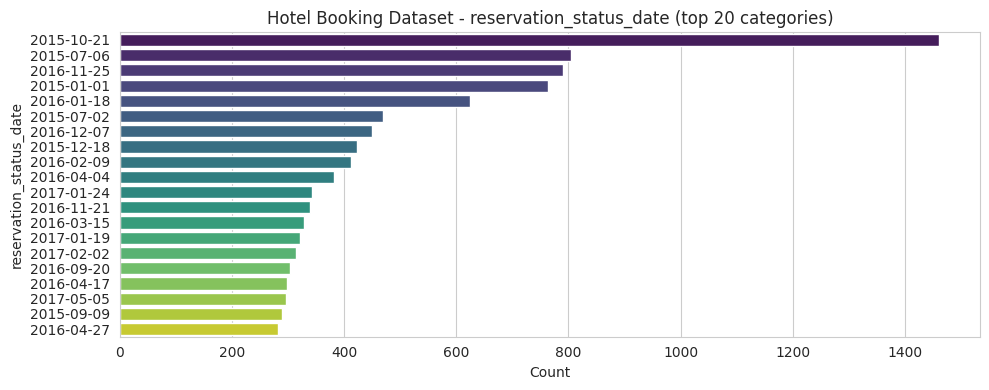

In [21]:
pii_cols = ['name', 'email', 'phone-number', 'credit_card']
plot_cols = [c for c in hotel_df.columns if c not in pii_cols]
analyze_every_column(hotel_df[plot_cols], "Hotel Booking Dataset", max_categories=20)


## 3.4 Outlier Detection (IQR method, numeric columns)

In [22]:
hotel_outliers = outlier_summary(hotel_df, "Hotel Booking Dataset")

===== Hotel Booking Dataset: IQR Outlier Summary =====


,column,lower_bound,upper_bound,num_outliers
7,adults,2.000,2.000,29710
13,booking_changes,0.000,0.000,18076
8,children,0.000,0.000,8590
18,required_car_parking_spaces,0.000,0.000,7416
11,previous_cancellations,0.000,0.000,6484
10,is_repeated_guest,0.000,0.000,3810
17,adr,-15.775,211.065,3793
16,days_in_waiting_list,0.000,0.000,3698
12,previous_bookings_not_canceled,0.000,0.000,3620
6,stays_in_week_nights,-2.000,6.000,3354


## 3.5 Data Cleaning

Cleaning steps applied:
1. **Drop PII columns**: `name`, `email`, `phone-number`, `credit_card` — not needed for analysis and pose a privacy risk if shared/published.
2. **`children`**: 4 missing values imputed with **0** (most common value / no children is the overwhelming default).
3. **`country`**: 488 missing values imputed with the **mode** (most frequent country of origin).
4. **`agent`**: missing (16,340 rows) means "no agent used" → imputed with `0` as a sentinel, then cast to int.
5. **`company`**: missing (112,593 rows, ~94%) means "no company involved" → imputed with `0` as a sentinel, then cast to int (column is otherwise dropped from most modeling use given the sparsity, but retained here with the sentinel for completeness).
6. **`adr` (average daily rate)**: one known negative/extreme outlier in the public version of this dataset — negative values are invalid and are clipped to 0; extreme high outliers capped at IQR bounds.
7. **Zero-guest bookings**: rows where `adults == 0` and `children == 0` and `babies == 0` (no guests at all) are invalid bookings and are dropped.
8. **Duplicates**: dropped exact duplicate rows (this dataset has a known large number of duplicates).
9. **`reservation_status_date`**: parsed to proper `datetime` dtype.
10. Categorical dtypes (`hotel`, `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`, `reservation_status`) cast to `category` dtype for memory efficiency.


In [23]:
hotel_clean = hotel_df.copy()

# 1. Drop PII columns
hotel_clean = hotel_clean.drop(columns=pii_cols)

# 2. children -> 0
hotel_clean['children'] = hotel_clean['children'].fillna(0)

# 3. country -> mode
hotel_clean['country'] = hotel_clean['country'].fillna(hotel_clean['country'].mode()[0])

# 4 & 5. agent/company -> sentinel 0 (no agent / no company)
hotel_clean['agent'] = hotel_clean['agent'].fillna(0).astype(int)
hotel_clean['company'] = hotel_clean['company'].fillna(0).astype(int)

# 6. adr: fix negative values, cap high outliers
hotel_clean['adr'] = hotel_clean['adr'].clip(lower=0)
q1, q3 = hotel_clean['adr'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5*iqr
hotel_clean['adr'] = hotel_clean['adr'].clip(upper=upper)

# 7. Remove zero-guest invalid bookings
zero_guest_mask = (hotel_clean['adults'] == 0) & (hotel_clean['children'] == 0) & (hotel_clean['babies'] == 0)
print(f"Removing {zero_guest_mask.sum()} invalid zero-guest bookings")
hotel_clean = hotel_clean[~zero_guest_mask]

# 8. Drop duplicates
before = hotel_clean.shape[0]
hotel_clean = hotel_clean.drop_duplicates()
print(f"Dropped {before - hotel_clean.shape[0]} duplicate rows")

# 9. Parse date
hotel_clean['reservation_status_date'] = pd.to_datetime(hotel_clean['reservation_status_date'])

# 10. Category dtypes
for col in ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'reservation_status']:
    hotel_clean[col] = hotel_clean[col].astype('category')

hotel_clean['children'] = hotel_clean['children'].astype(int)

print("\nRemaining missing values after cleaning:")
print(hotel_clean.isnull().sum().sum())
print("\nFinal shape:", hotel_clean.shape)
hotel_clean.head()


Removing 180 invalid zero-guest bookings


Dropped 32017 duplicate rows



Remaining missing values after cleaning:
0

Final shape: (87193, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3.6 Post-Cleaning Correlation Heatmap (numeric columns)

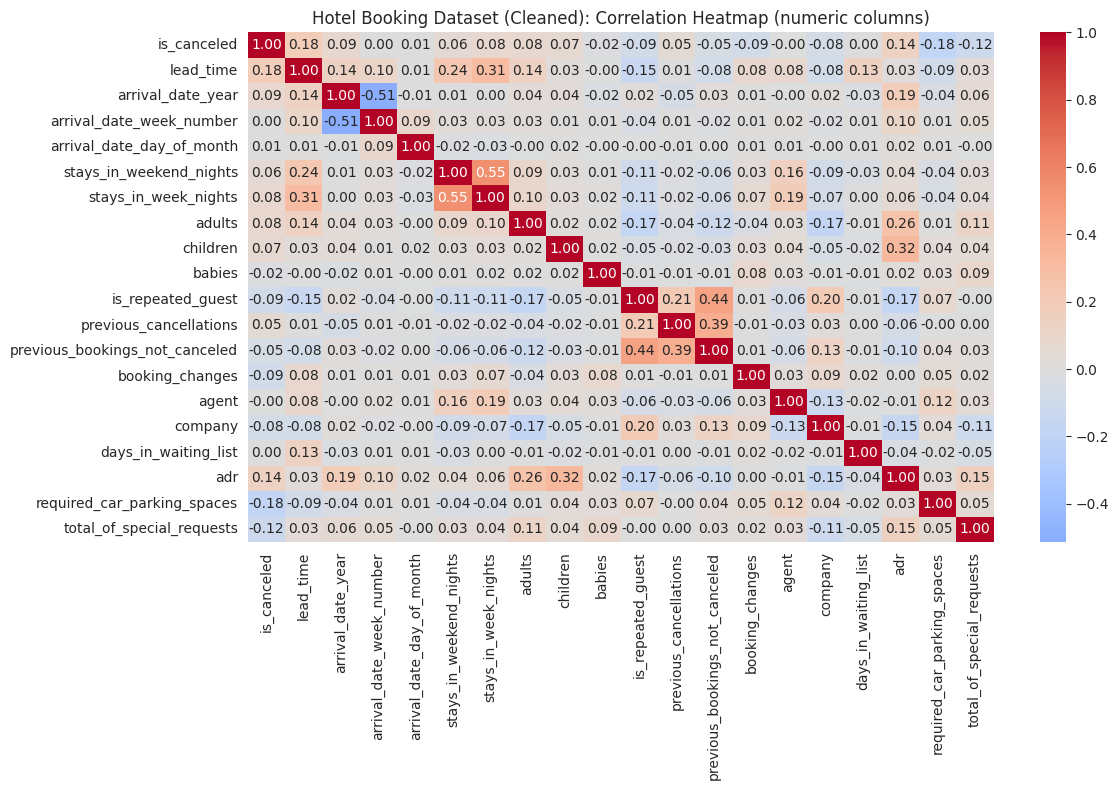

In [24]:
correlation_heatmap(hotel_clean, "Hotel Booking Dataset (Cleaned)")

## 3.7 Key Relationships & Target Check (`is_canceled`)

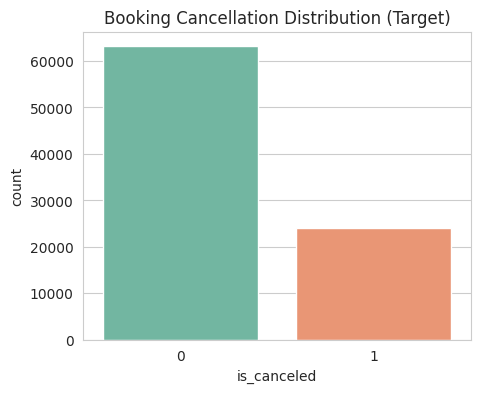

is_canceled
0    0.724726
1    0.275274
Name: proportion, dtype: float64


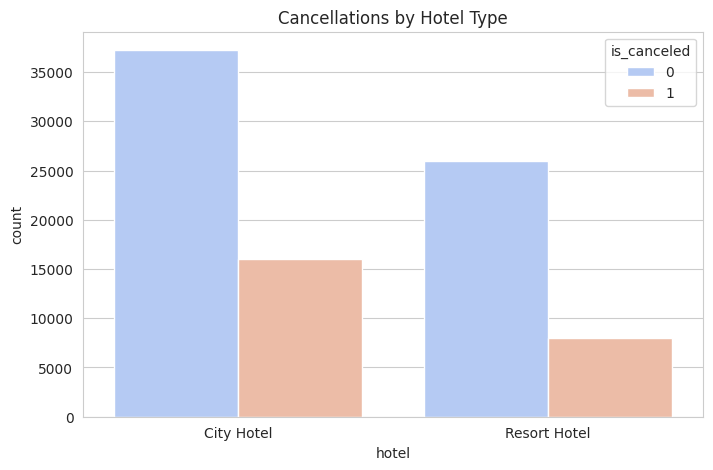

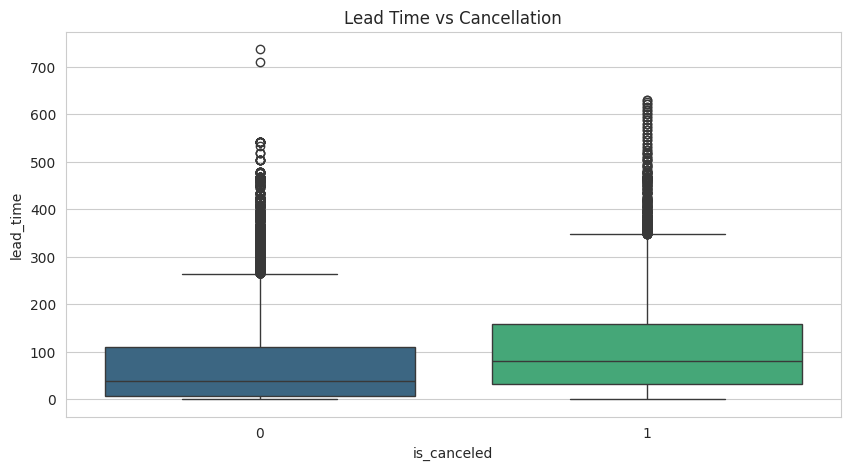

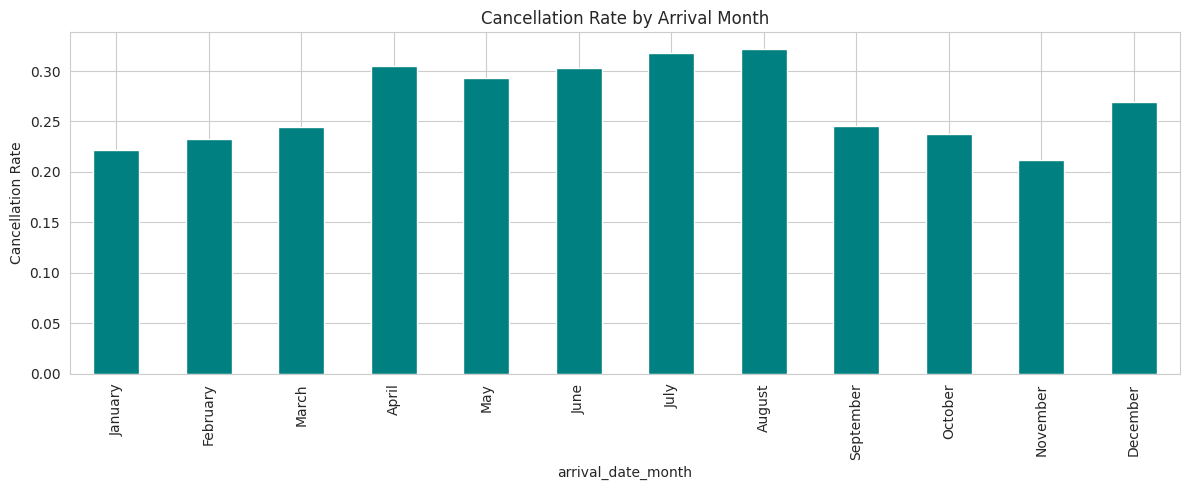

In [25]:
plt.figure(figsize=(5,4))
sns.countplot(x='is_canceled', data=hotel_clean, palette='Set2')
plt.title("Booking Cancellation Distribution (Target)")
plt.show()
print(hotel_clean['is_canceled'].value_counts(normalize=True))

plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled', data=hotel_clean, palette='coolwarm')
plt.title("Cancellations by Hotel Type")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='is_canceled', y='lead_time', data=hotel_clean, palette='viridis')
plt.title("Lead Time vs Cancellation")
plt.show()

monthly = hotel_clean.groupby('arrival_date_month')['is_canceled'].mean().reindex(
    ['January','February','March','April','May','June','July','August','September','October','November','December']
)
plt.figure(figsize=(12,5))
monthly.plot(kind='bar', color='teal')
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Arrival Month')
plt.tight_layout()
plt.show()


## 3.8 Export Cleaned Dataset

In [26]:
hotel_clean.to_csv('hotel_booking_cleaned.csv', index=False)
print("Saved: hotel_booking_cleaned.csv | shape:", hotel_clean.shape)


Saved: hotel_booking_cleaned.csv | shape: (87193, 32)


---
# Summary

| Dataset | Original Shape | Cleaned Shape | Key Cleaning Actions |
|---|---|---|---|
| Loan Eligibility | 1614 x 13 | see output above | Fixed `Dependents` encoding, imputed categorical/numeric missing values, capped `LoanAmount` outliers, dropped duplicates |
| Adult Census Income | 48842 x 15 | see output above | Replaced `'?'` with NaN, imputed `workclass`/`occupation`/`native-country`, capped `age`/`hours-per-week` outliers, standardized `income` labels |
| Hotel Booking | 119390 x 36 | see output above | Dropped PII columns, imputed `children`/`country`/`agent`/`company`, fixed invalid `adr` and zero-guest rows, parsed dates, dropped duplicates |

All three cleaned datasets have been exported as CSV files: `loan_train_cleaned.csv`, `adult_cleaned.csv`, `hotel_booking_cleaned.csv`.
